# Machine Learning e Explainable AI na Identificação de Fatores que Influenciam o Churn de Clientes Bancários

Karine Cerqueira Nascimento  
Universidade de São Paulo (USP)  
Instituto de Ciências Matemáticas e de Computação (ICMC)

Este notebook apresenta o desenvolvimento completo do projeto de predição de churn bancário utilizando técnicas de aprendizado de máquina e Explainable Artificial Intelligence (XAI).

#### Importando bibliotecas

In [1]:
# Bibliotecas principais
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

import shap
import xgboost as xgb

#### Configurações de Ambiente

In [2]:
# Configuração visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

#### Leitura dos Dados

In [3]:
df = pd.read_csv(r"../data/data_churn.csv")

df.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377


In [4]:
base = df.copy()

Descrição do Dataset

O conjunto de dados utilizado neste trabalho contém informações de clientes de uma instituição bancária, com o objetivo de analisar e prever o fenômeno de churn, ou seja, a evasão de clientes.

Cada linha do dataset representa um cliente, e as colunas correspondem a diferentes características demográficas, financeiras e comportamentais. A seguir, são descritas as principais variáveis:

- **RowNumber**: corresponde ao número da linha no dataset, não possuindo relevância analítica para o modelo.

- **CustomerId**: identificador único do cliente. Trata-se de um valor aleatório que não influencia a decisão de churn.

- **Surname**: sobrenome do cliente, não sendo uma variável relevante para a predição.

- **CreditScore**: pontuação de crédito do cliente. Clientes com maior score tendem a apresentar menor probabilidade de evasão.

- **Geography**: localização geográfica do cliente, podendo influenciar o comportamento de churn.

- **Gender**: gênero do cliente. Pode ser analisado para verificar possíveis diferenças comportamentais.

- **Age**: idade do cliente. Clientes mais jovens tendem a apresentar maior propensão ao churn em comparação com clientes mais velhos.

- **Tenure**: tempo (em anos) que o cliente permanece na instituição. Em geral, clientes com maior tempo de relacionamento tendem a ser mais fiéis.

- **Balance**: saldo da conta bancária. Clientes com maiores saldos tendem a apresentar menor probabilidade de evasão.

- **NumOfProducts**: número de produtos contratados pelo cliente junto ao banco.

- **HasCrCard**: indica se o cliente possui cartão de crédito. Clientes com cartão tendem a ser mais engajados.

- **IsActiveMember**: indica se o cliente é ativo. Clientes ativos apresentam menor probabilidade de churn.

- **EstimatedSalary**: salário estimado do cliente. Pode influenciar a decisão de permanência.

- **Exited**: variável alvo do problema, indicando se o cliente deixou a instituição (1) ou não (0).

- **Complain**: indica se o cliente realizou alguma reclamação.

- **Satisfaction Score**: nível de satisfação do cliente em relação ao atendimento ou resolução de problemas.

- **Card Type**: tipo de cartão possuído pelo cliente.

- **Points Earned**: quantidade de pontos acumulados pelo uso do cartão de crédito.

In [5]:
df.rename(columns={
    "RowNumber": "NumeroLinha",
    "CustomerId": "IdCliente",
    "Surname": "Sobrenome",
    "CreditScore": "PontuacaoCredito",
    "Geography": "Localizacao",
    "Gender": "Genero",
    "Age": "Idade",
    "Tenure": "TempoRelacionamento",
    "Balance": "Saldo",
    "NumOfProducts": "NumeroProdutos",
    "HasCrCard": "PossuiCartaoCredito",
    "IsActiveMember": "MembroAtivo",
    "EstimatedSalary": "SalarioEstimado",
    "Exited": "Churn",
    "Complain": "Reclamacao",
    "Satisfaction Score": "NivelSatisfacao",
    "Card Type": "TipoCartao",
    "Point Earned": "PontosAcumulados"
}, inplace=True)

In [6]:
df.head(1)

,NumeroLinha,IdCliente,Sobrenome,PontuacaoCredito,Localizacao,Genero,Idade,TempoRelacionamento,Saldo,NumeroProdutos,PossuiCartaoCredito,MembroAtivo,SalarioEstimado,Churn,Reclamacao,NivelSatisfacao,TipoCartao,PontosAcumulados
0,1,15634602,Hargrave,619,France,Female,42,2,0.0,1,1,1,101348.88,1,1,2,DIAMOND,464


#### Visão Geral dos Dados

In [7]:
df.shape

(10000, 18)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   NumeroLinha          10000 non-null  int64  
 1   IdCliente            10000 non-null  int64  
 2   Sobrenome            10000 non-null  str    
 3   PontuacaoCredito     10000 non-null  int64  
 4   Localizacao          10000 non-null  str    
 5   Genero               10000 non-null  str    
 6   Idade                10000 non-null  int64  
 7   TempoRelacionamento  10000 non-null  int64  
 8   Saldo                10000 non-null  float64
 9   NumeroProdutos       10000 non-null  int64  
 10  PossuiCartaoCredito  10000 non-null  int64  
 11  MembroAtivo          10000 non-null  int64  
 12  SalarioEstimado      10000 non-null  float64
 13  Churn                10000 non-null  int64  
 14  Reclamacao           10000 non-null  int64  
 15  NivelSatisfacao      10000 non-null  int64  
 16

In [9]:
df.describe()

,NumeroLinha,IdCliente,PontuacaoCredito,Idade,TempoRelacionamento,Saldo,NumeroProdutos,PossuiCartaoCredito,MembroAtivo,SalarioEstimado,Churn,Reclamacao,NivelSatisfacao,PontosAcumulados
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


#### Verificar valores nulos

In [10]:
df.isnull().sum()

NumeroLinha            0
IdCliente              0
Sobrenome              0
PontuacaoCredito       0
Localizacao            0
Genero                 0
Idade                  0
TempoRelacionamento    0
Saldo                  0
NumeroProdutos         0
PossuiCartaoCredito    0
MembroAtivo            0
SalarioEstimado        0
Churn                  0
Reclamacao             0
NivelSatisfacao        0
TipoCartao             0
PontosAcumulados       0
dtype: int64

#### Limpeza

In [11]:
# Remover colunas irrelevantes
df.drop(["NumeroLinha", "IdCliente", "Sobrenome"], axis=1, inplace=True)

#### Análise do Target (Churn)

In [12]:
df["Churn"].value_counts()

Churn
0    7962
1    2038
Name: count, dtype: int64

Churn de 20,38%

#### EDA

Pontuação Crédito

In [13]:
tabela = pd.crosstab(
    df["PontuacaoCredito"],
    df["Churn"],
    normalize="index"
) * 100

tabela.round(2)

Churn,0,1
PontuacaoCredito,,
350,0.00,100.00
351,0.00,100.00
358,0.00,100.00
359,0.00,100.00
363,0.00,100.00
...,...,...
846,60.00,40.00
847,66.67,33.33
848,100.00,0.00


In [14]:
def faixa_risco_credito(score):
    if score <= 404:
        return "Alto"
    elif score <= 500:
        return "Medio"
    elif score <= 650:
        return "Baixo"
    else:
        return "Muito_baixo"

df["RiscoCredito"] = df["PontuacaoCredito"].apply(faixa_risco_credito)

In [15]:
df["RiscoCredito"].value_counts()

RiscoCredito
Muito_baixo    5063
Baixo          4294
Medio           622
Alto             21
Name: count, dtype: int64

In [16]:
pd.crosstab(
    df["RiscoCredito"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
RiscoCredito,,
Alto,0.000000,100.000000
Baixo,78.924080,21.075920
Medio,78.938907,21.061093
Muito_baixo,80.624136,19.375864


Localização

In [17]:
tabela = pd.crosstab(df["Localizacao"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
Localizacao,,
France,83.83,16.17
Germany,67.56,32.44
Spain,83.33,16.67


Genero

In [18]:
tabela = pd.crosstab(df["Genero"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
Genero,,
Female,74.93,25.07
Male,83.53,16.47


Idade 🔸

In [19]:
tabela = pd.crosstab(df["Idade"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
Idade,,
18,90.91,9.09
19,96.30,3.70
20,95.00,5.00
21,94.34,5.66
22,85.71,14.29
...,...,...
83,100.00,0.00
84,50.00,50.00
85,100.00,0.00


In [20]:
df["IdadeAltoChurn"] = (
    (df["Idade"] >= 45) &
    (df["Idade"] <= 60)
).astype(int)

In [21]:
bins = [18, 30, 40, 50, 60, 100]

labels = [
    "Jovem",
    "Adulto",
    "Meia_Idade",
    "Senior",
    "Idoso"
]

df["FaixaEtaria"] = pd.cut(
    df["Idade"],
    bins=bins,
    labels=labels
)

In [22]:
pd.crosstab(
    df["FaixaEtaria"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
FaixaEtaria,,
Jovem,92.497431,7.502569
Adulto,87.890362,12.109638
Meia_Idade,66.034483,33.965517
Senior,43.789210,56.210790
Idoso,75.215517,24.784483


Tempo de Relacionamento

In [23]:
tabela = pd.crosstab(df["TempoRelacionamento"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
TempoRelacionamento,,
0,77.00,23.00
1,77.58,22.42
2,80.82,19.18
3,78.89,21.11
4,79.47,20.53
5,79.35,20.65
6,79.73,20.27
7,82.78,17.22
8,80.78,19.22


In [24]:
df["ClienteNovo"] = (
    df["TempoRelacionamento"] <= 2
).astype(int)

In [25]:
df["ClienteAntigo"] = (
    df["TempoRelacionamento"] >= 7
).astype(int)

Saldo

In [26]:
tabela = pd.crosstab(df["Saldo"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
Saldo,,
0.00,86.18,13.82
3768.69,0.00,100.00
12459.19,0.00,100.00
14262.80,100.00,0.00
16893.59,100.00,0.00
...,...,...
216109.88,0.00,100.00
221532.80,100.00,0.00
222267.63,0.00,100.00


In [27]:
import pandas as pd
import numpy as np

# Criar faixas de 1000 em 1000
bins = np.arange(0, df["Saldo"].max() + 1000, 1000)

# Criar coluna categórica
df["FaixaSaldo"] = pd.cut(df["Saldo"], bins=bins)

# Crosstab
tabela = pd.crosstab(
    df["FaixaSaldo"],
    df["Churn"],
    normalize="index"
) * 100

tabela.round(2)

Churn,0,1
FaixaSaldo,,
"(3000.0, 4000.0]",0.0,100.0
"(12000.0, 13000.0]",0.0,100.0
"(14000.0, 15000.0]",100.0,0.0
"(16000.0, 17000.0]",100.0,0.0
"(23000.0, 24000.0]",0.0,100.0
...,...,...
"(216000.0, 217000.0]",0.0,100.0
"(221000.0, 222000.0]",100.0,0.0
"(222000.0, 223000.0]",0.0,100.0


In [28]:
df["SemSaldo"] = (
    df["Saldo"] == 0
).astype(int)

In [29]:
df["SaldoAlto"] = (
    df["Saldo"] >= 100000
).astype(int)

In [30]:
df["FaixaSaldo"] = pd.cut(
    df["Saldo"],
    bins=[-1, 0, 50000, 100000, 150000, 300000],
    labels=["Zero", "Baixo", "Médio", "Alto", "Muito Alto"]
)

tabela = pd.crosstab(df["FaixaSaldo"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
FaixaSaldo,,
Zero,86.18,13.82
Baixo,65.33,34.67
Médio,80.05,19.95
Alto,74.23,25.77
Muito Alto,76.88,23.12


Número de Produtos

In [31]:
tabela = pd.crosstab(df["NumeroProdutos"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
NumeroProdutos,,
1,72.29,27.71
2,92.40,7.60
3,17.29,82.71
4,0.00,100.00


In [32]:
df['NumeroProdutos'].value_counts()

NumeroProdutos
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [33]:
df["MultiProduto"] = (
    
    df["NumeroProdutos"] >= 3
).astype(int)

In [34]:
df["PerfilIdealProdutos"] = (
    df["NumeroProdutos"] == 2
).astype(int)

Possui cartão de crédito

In [35]:
tabela = pd.crosstab(df["PossuiCartaoCredito"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
PossuiCartaoCredito,,
0,79.19,20.81
1,79.80,20.20


Membro Ativo

In [36]:
tabela = pd.crosstab(df["MembroAtivo"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
MembroAtivo,,
0,73.13,26.87
1,85.73,14.27


Salário

In [37]:
# Criar faixas de 1000 em 1000
bins = np.arange(0, df["SalarioEstimado"].max() + 5000, 5000)

# Criar coluna categórica
df["FaixaSalario"] = pd.cut(df["SalarioEstimado"], bins=bins)

# Crosstab
tabela = pd.crosstab(
    df["FaixaSalario"],
    df["Churn"],
    normalize="index"
) * 100

tabela.round(2)

Churn,0,1
FaixaSalario,,
"(0.0, 5000.0]",84.09,15.91
"(5000.0, 10000.0]",75.82,24.18
"(10000.0, 15000.0]",79.75,20.25
"(15000.0, 20000.0]",79.66,20.34
"(20000.0, 25000.0]",80.95,19.05
"(25000.0, 30000.0]",77.01,22.99
"(30000.0, 35000.0]",77.92,22.08
"(35000.0, 40000.0]",83.54,16.46
"(40000.0, 45000.0]",80.08,19.92


In [38]:
df["FaixaSalario"] = pd.qcut(df["SalarioEstimado"], q=5)

tabela = pd.crosstab(df["FaixaSalario"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
FaixaSalario,,
"(11.579, 41050.736]",80.05,19.95
"(41050.736, 80238.34]",80.05,19.95
"(80238.34, 119710.038]",79.80,20.20
"(119710.038, 159836.726]",79.80,20.20
"(159836.726, 199992.48]",78.40,21.60


Reclamação 🔸

In [39]:
tabela = pd.crosstab(df["Reclamacao"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
Reclamacao,,
0,99.95,0.05
1,0.49,99.51


Durante a análise exploratória, observou-se que a variável relacionada a reclamações apresentava associação praticamente determinística com a variável alvo de churn, indicando forte possibilidade de data leakage. Dessa forma, optou-se pela remoção da variável para evitar vazamento de informação e garantir validade preditiva do modelo.

Nível de Satisfação 🔸

In [40]:
tabela = pd.crosstab(df["NivelSatisfacao"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
NivelSatisfacao,,
1,79.97,20.03
2,78.20,21.80
3,80.36,19.64
4,79.38,20.62
5,80.19,19.81


Tipo de Cartão 🔸

In [41]:
tabela = pd.crosstab(df["TipoCartao"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
TipoCartao,,
DIAMOND,78.22,21.78
GOLD,80.74,19.26
PLATINUM,79.64,20.36
SILVER,79.89,20.11


Pontos Acumulados

In [42]:
df["FaixaPontos"] = pd.qcut(df["PontosAcumulados"], q=10)

tabela = pd.crosstab(df["FaixaPontos"], df["Churn"], normalize="index") * 100
tabela.round(2)

Churn,0,1
FaixaPontos,,
"(118.999, 295.0]",78.44,21.56
"(295.0, 370.0]",79.10,20.90
"(370.0, 452.0]",79.54,20.46
"(452.0, 529.0]",82.37,17.63
"(529.0, 605.0]",79.98,20.02
"(605.0, 682.0]",78.56,21.44
"(682.0, 762.0]",77.72,22.28
"(762.0, 840.0]",78.20,21.80
"(840.0, 921.0]",81.67,18.33


Engenharia de Atributos

In [43]:
from itertools import combinations
import pandas as pd

colunas = [
    "PontuacaoCredito",
    "Localizacao",
    "Genero",
    "Idade",
    "TempoRelacionamento",
    "Saldo",
    "NumeroProdutos",
    "PossuiCartaoCredito",
    "MembroAtivo",
    "SalarioEstimado",
    "NivelSatisfacao",
    "TipoCartao",
    "PontosAcumulados",
    "FaixaPontos",
    "FaixaSaldo",
    "RiscoCredito",
    "IdadeAltoChurn",
    "FaixaEtaria",
    "ClienteNovo",
    "ClienteAntigo",
    "SemSaldo",
    "SaldoAlto",
    "MultiProduto",
    "PerfilIdealProdutos",
    "FaixaSalario"
]

resultados = []

for c1, c2 in combinations(colunas, 2):

    grupo = df.groupby([c1, c2])["Churn"].agg(
        ["mean", "count"]
    ).reset_index()

    grupo["mean"] *= 100
    grupo["comb"] = f"{c1} + {c2}"

    resultados.append(grupo)

resultado_final = pd.concat(resultados)

resultado_final = resultado_final.sort_values(
    by="mean",
    ascending=False
)

# resultado_final.head(30)

resultado_filtrado = resultado_final[
    resultado_final["count"] >= 100
]

resultado_filtrado = resultado_filtrado.sort_values(
    by="mean",
    ascending=False
)

resultado_filtrado.head(5)

,PontuacaoCredito,Localizacao,mean,count,comb,Genero,Idade,TempoRelacionamento,Saldo,NumeroProdutos,...,RiscoCredito,IdadeAltoChurn,FaixaEtaria,ClienteNovo,ClienteAntigo,SemSaldo,SaldoAlto,MultiProduto,PerfilIdealProdutos,FaixaSalario
3,NaN,NaN,99.186992,123,IdadeAltoChurn + MultiProduto,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
7,NaN,NaN,95.588235,136,FaixaSaldo + MultiProduto,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
1,NaN,NaN,95.327103,214,SemSaldo + MultiProduto,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN
3,NaN,NaN,95.238095,168,SaldoAlto + MultiProduto,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN
5,NaN,NaN,94.308943,123,FaixaEtaria + MultiProduto,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Meia_Idade,NaN,NaN,NaN,NaN,1.0,NaN,NaN


Observou-se que clientes com três ou mais produtos apresentaram taxas extremamente elevadas de churn, comportamento que difere parcialmente do esperado em cenários bancários reais. Tal resultado pode indicar padrões específicos do dataset utilizado ou possíveis vieses de amostragem.

In [44]:
df["ClienteRiscoMaximo"] = (
    (df["NumeroProdutos"] >= 3) &
    (df["MembroAtivo"] == 0)
).astype(int)

In [45]:
df["MultiProdutoAlemanha"] = (
    (df["NumeroProdutos"] >= 3) &
    (df["Localizacao"] == "Germany")
).astype(int)

In [46]:
df["MultiProdutoIdadeAlta"] = (
    (df["NumeroProdutos"] >= 3) &
    (df["Idade"] >= 50)
).astype(int)

Gráficos

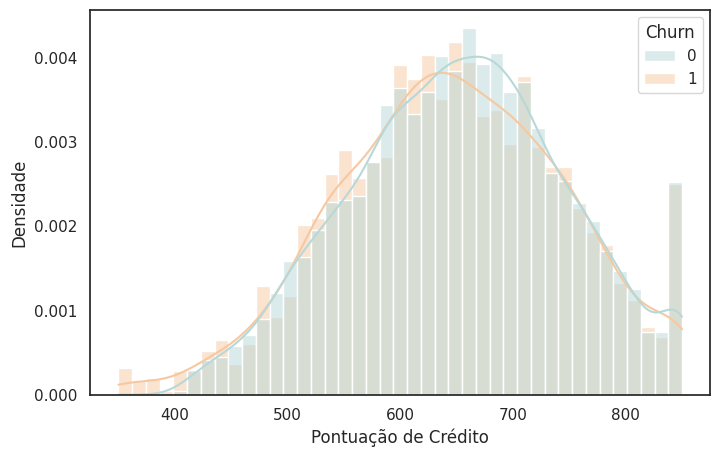

In [47]:
sns.set_style("white")

plt.figure(figsize=(8,5))

sns.histplot(

    data=df,

    x="PontuacaoCredito",

    hue="Churn",

    kde=True,

    stat="density",

    common_norm=False,

    palette=["#B8D8D8", "#F7C8A0"]
)

plt.xlabel(
    "Pontuação de Crédito",
    fontsize=12
)

plt.ylabel(
    "Densidade",
    fontsize=12
)

plt.show()

/tmp/ipykernel_21533/1005868111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


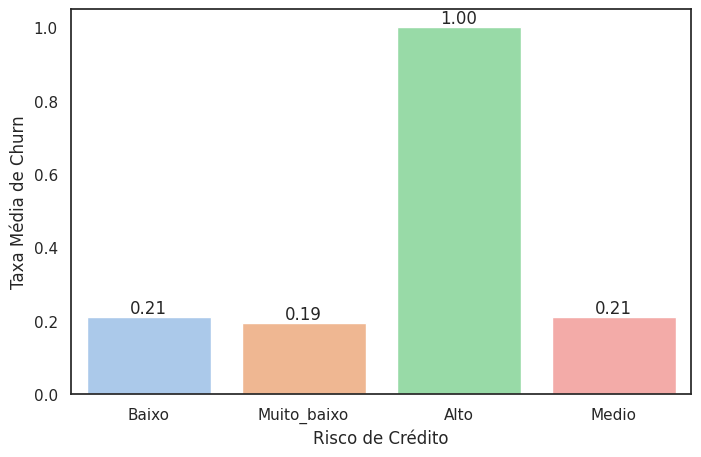

In [48]:
plt.figure(figsize=(8,5))

ax = sns.barplot(

    x="RiscoCredito",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

plt.xlabel("Risco de Crédito")
plt.ylabel("Taxa Média de Churn")

plt.show()

/tmp/ipykernel_21533/1549276092.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


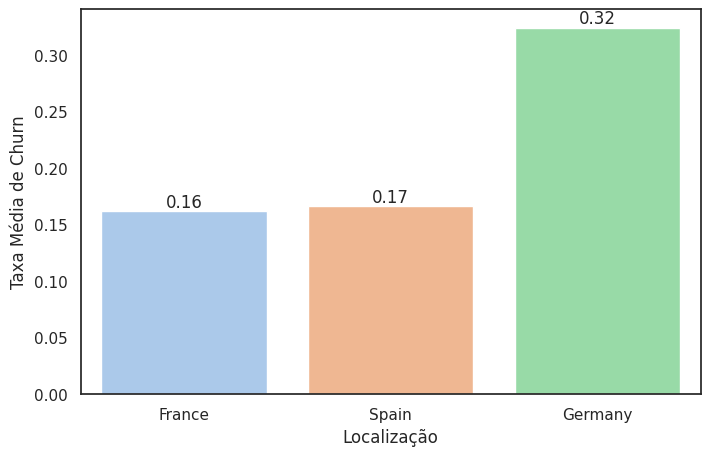

In [49]:
plt.figure(figsize=(8,5))

ax = sns.barplot(

    x="Localizacao",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

plt.xlabel("Localização")
plt.ylabel("Taxa Média de Churn")

plt.show()

/tmp/ipykernel_21533/3632048597.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


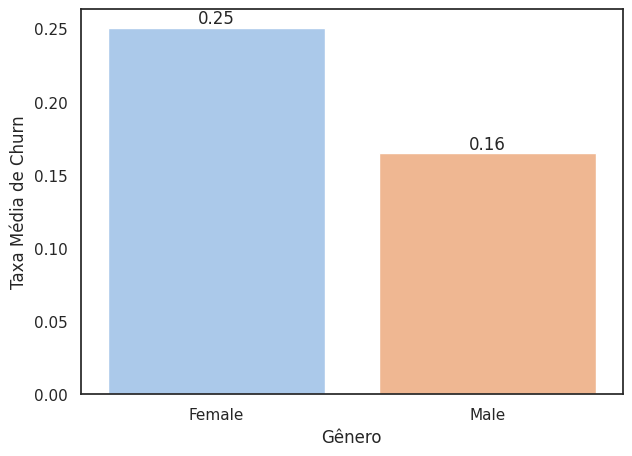

In [50]:
plt.figure(figsize=(7,5))

ax = sns.barplot(

    x="Genero",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

plt.xlabel("Gênero")
plt.ylabel("Taxa Média de Churn")

plt.show()

/tmp/ipykernel_21533/927491222.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


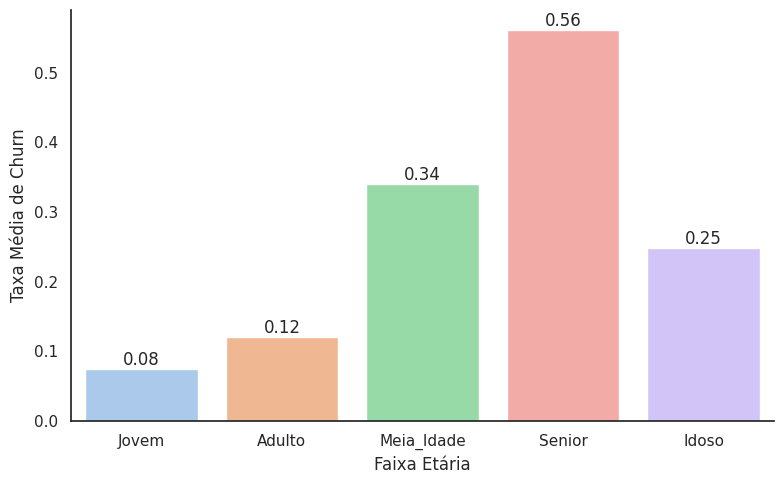

In [51]:
plt.figure(figsize=(8,5))

ax = sns.barplot(

    x="FaixaEtaria",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

plt.xlabel("Faixa Etária")
plt.ylabel("Taxa Média de Churn")

sns.despine()

plt.tight_layout()

plt.show()

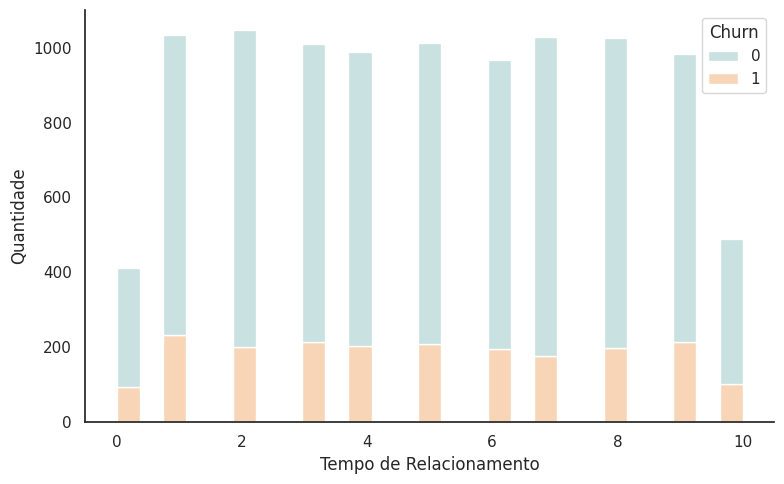

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(

    data=df,

    x="TempoRelacionamento",

    hue="Churn",

    multiple="stack",

    palette=["#B8D8D8", "#F7C8A0"]
)

plt.xlabel("Tempo de Relacionamento")
plt.ylabel("Quantidade")

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_21533/1247358426.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


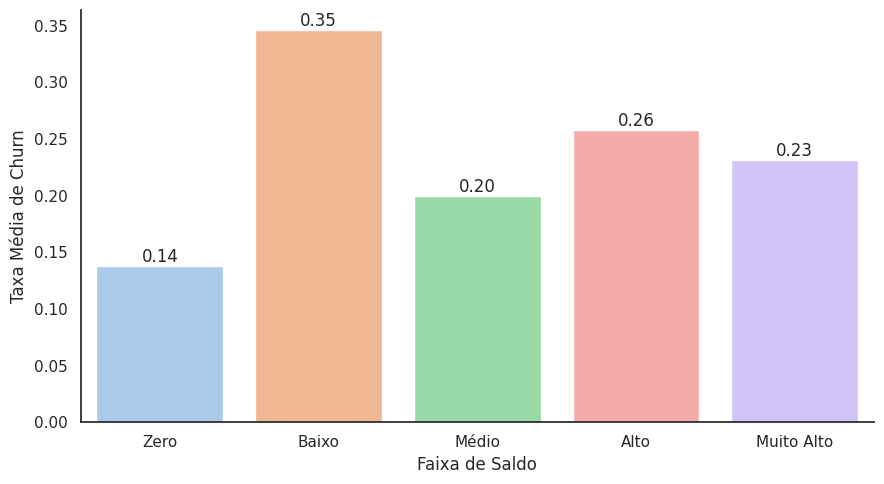

In [53]:
plt.figure(figsize=(9,5))

ax = sns.barplot(

    x="FaixaSaldo",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

plt.xlabel("Faixa de Saldo")
plt.ylabel("Taxa Média de Churn")

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_21533/3576664184.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


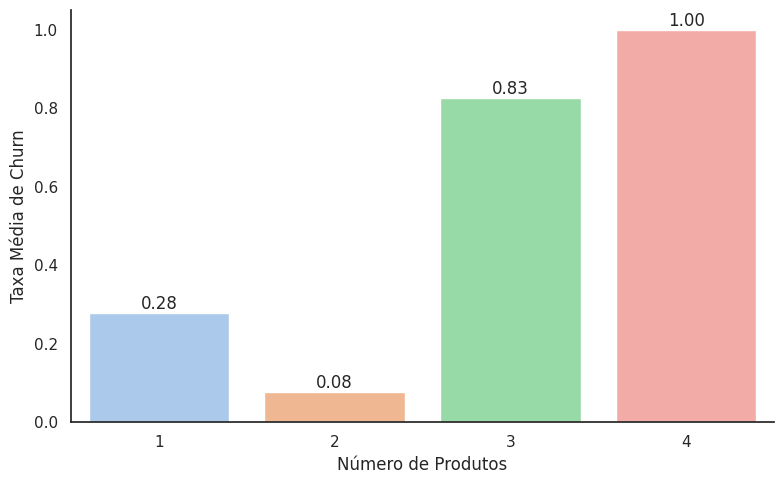

In [54]:
plt.figure(figsize=(8,5))

ax = sns.barplot(

    x="NumeroProdutos",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

plt.xlabel("Número de Produtos")
plt.ylabel("Taxa Média de Churn")

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_21533/1471819580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_21533/1471819580.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


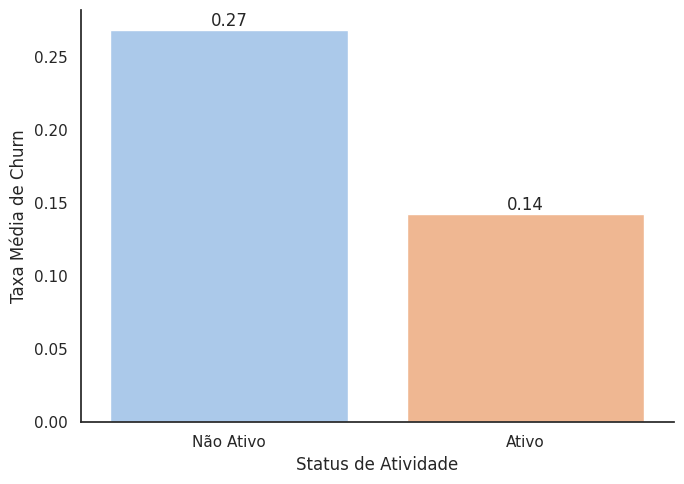

In [55]:
plt.figure(figsize=(7,5))

ax = sns.barplot(

    x="MembroAtivo",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

ax.set_xticklabels([
    "Não Ativo",
    "Ativo"
])

plt.xlabel("Status de Atividade")
plt.ylabel("Taxa Média de Churn")

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_21533/2684026597.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_21533/2684026597.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


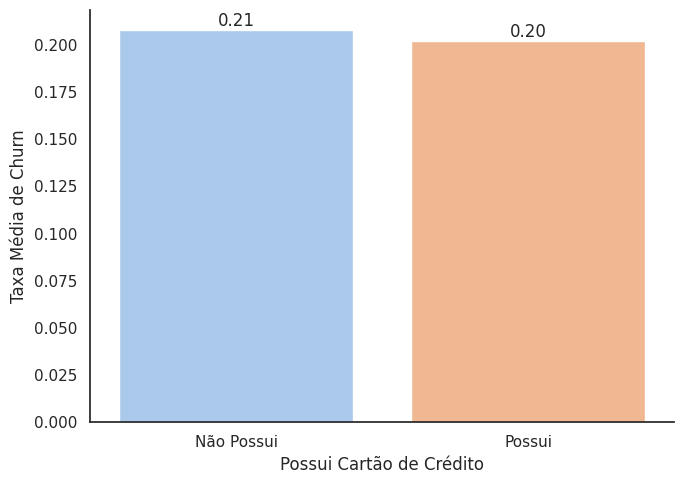

In [56]:
plt.figure(figsize=(7,5))

ax = sns.barplot(

    x="PossuiCartaoCredito",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

ax.set_xticklabels([
    "Não Possui",
    "Possui"
])

plt.xlabel(
    "Possui Cartão de Crédito",
    fontsize=12
)

plt.ylabel(
    "Taxa Média de Churn",
    fontsize=12
)

sns.despine()

plt.tight_layout()

plt.show()

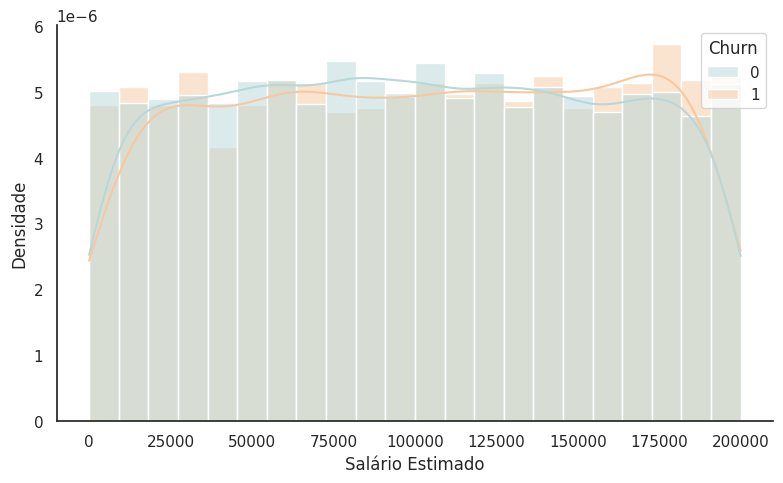

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(

    data=df,

    x="SalarioEstimado",

    hue="Churn",

    kde=True,

    stat="density",

    common_norm=False,

    palette=["#B8D8D8", "#F7C8A0"]
)

plt.xlabel("Salário Estimado")
plt.ylabel("Densidade")

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_21533/1293330568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


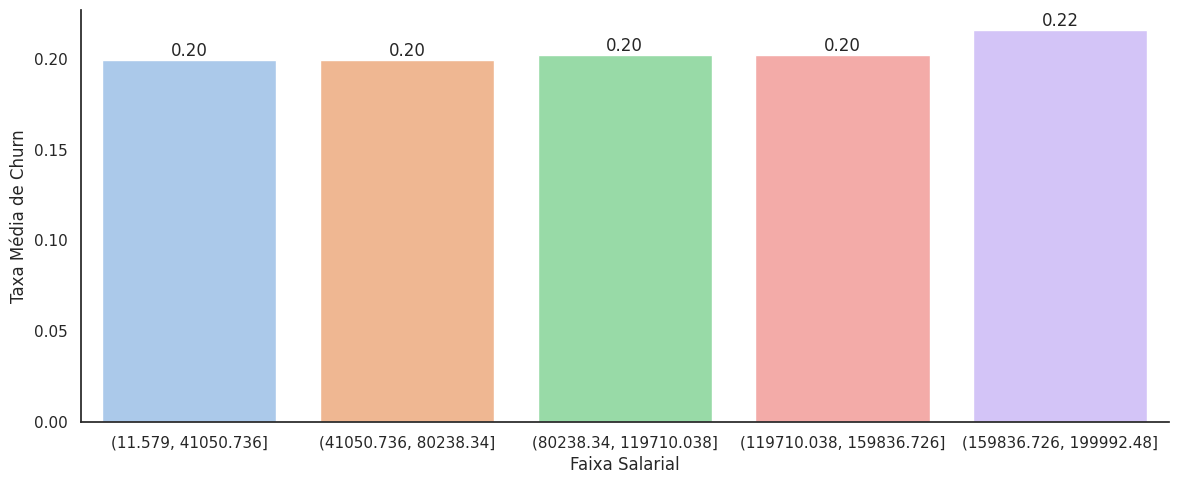

In [58]:
plt.figure(figsize=(12,5))

ax = sns.barplot(

    x="FaixaSalario",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

plt.xlabel("Faixa Salarial")
plt.ylabel("Taxa Média de Churn")

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_21533/765445726.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_21533/765445726.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


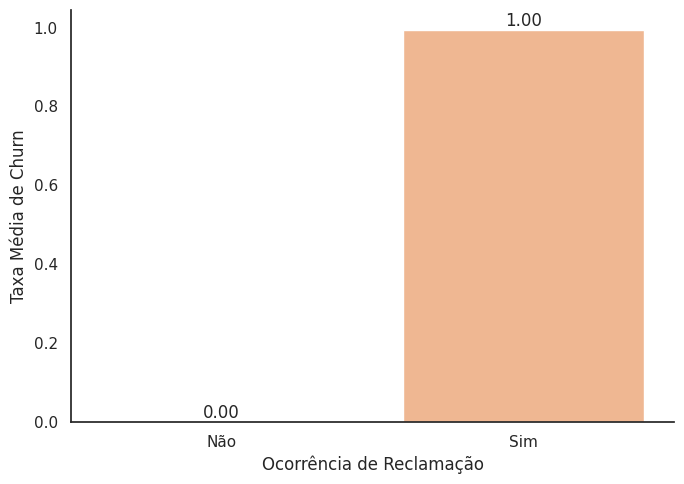

In [59]:
plt.figure(figsize=(7,5))

ax = sns.barplot(

    x="Reclamacao",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

ax.set_xticklabels([
    "Não",
    "Sim"
])

plt.xlabel("Ocorrência de Reclamação")
plt.ylabel("Taxa Média de Churn")

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_21533/3574293839.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


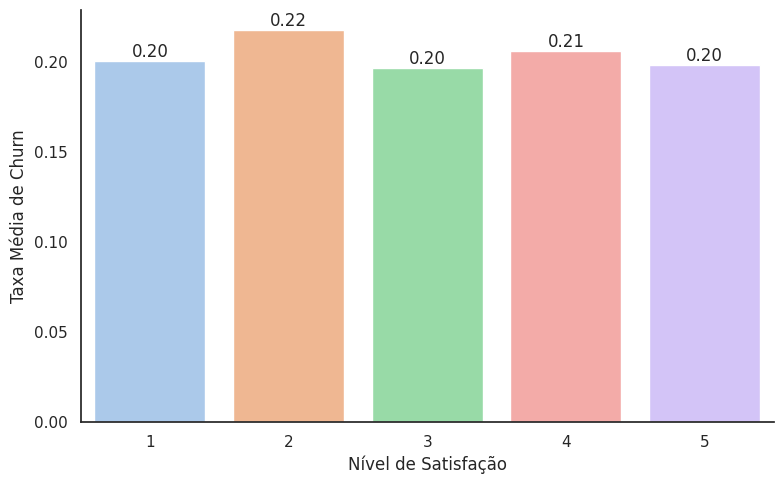

In [60]:
plt.figure(figsize=(8,5))

ax = sns.barplot(

    x="NivelSatisfacao",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

plt.xlabel("Nível de Satisfação")
plt.ylabel("Taxa Média de Churn")

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_21533/511780107.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


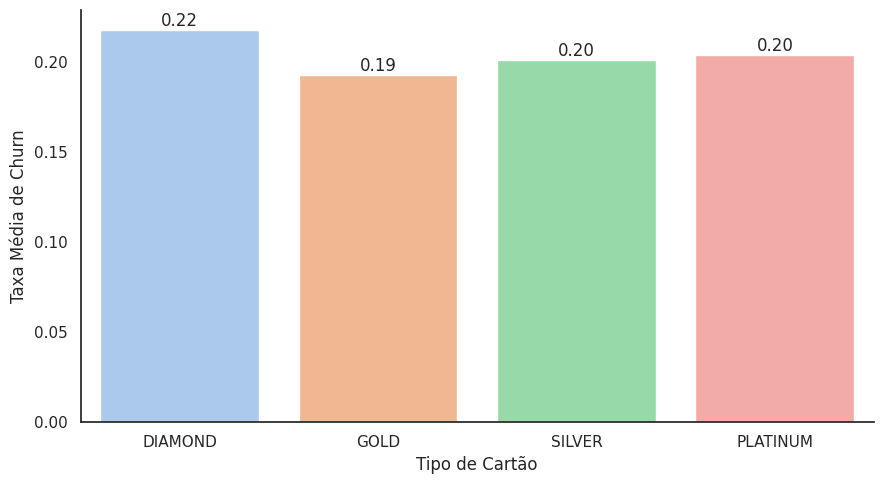

In [61]:
plt.figure(figsize=(9,5))

ax = sns.barplot(

    x="TipoCartao",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

plt.xlabel("Tipo de Cartão")
plt.ylabel("Taxa Média de Churn")

sns.despine()

plt.tight_layout()

plt.show()

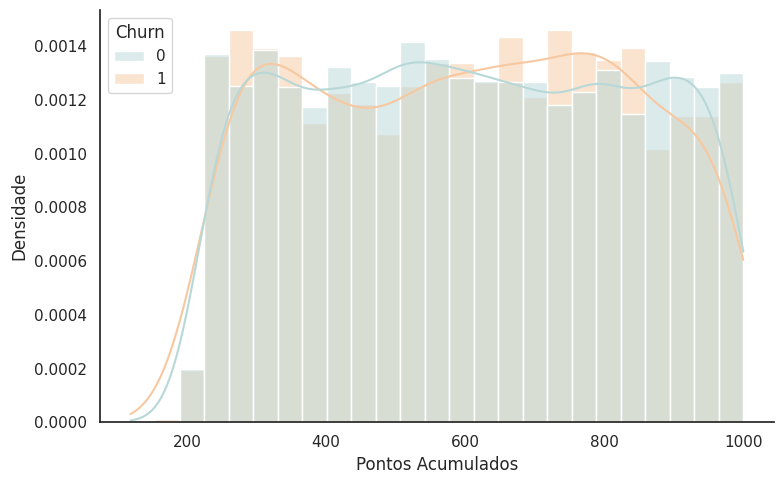

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(

    data=df,

    x="PontosAcumulados",

    hue="Churn",

    kde=True,

    stat="density",

    common_norm=False,

    palette=["#B8D8D8", "#F7C8A0"]
)

plt.xlabel("Pontos Acumulados")
plt.ylabel("Densidade")

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_21533/3735295582.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


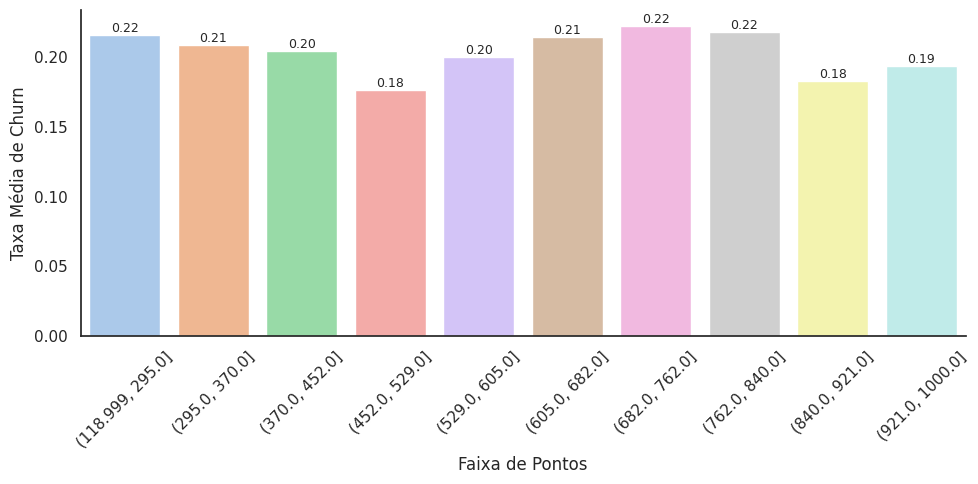

In [63]:
plt.figure(figsize=(10,5))

ax = sns.barplot(

    x="FaixaPontos",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom',

        fontsize=9
    )

plt.xlabel("Faixa de Pontos")
plt.ylabel("Taxa Média de Churn")

plt.xticks(rotation=45)

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_21533/3813772809.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_21533/3813772809.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


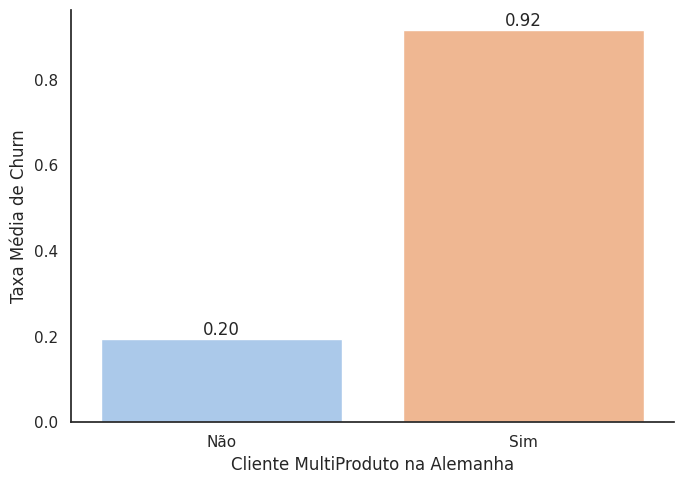

In [64]:
plt.figure(figsize=(7,5))

ax = sns.barplot(

    x="MultiProdutoAlemanha",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

ax.set_xticklabels([
    "Não",
    "Sim"
])

plt.xlabel("Cliente MultiProduto na Alemanha")
plt.ylabel("Taxa Média de Churn")

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_21533/1083882685.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_21533/1083882685.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


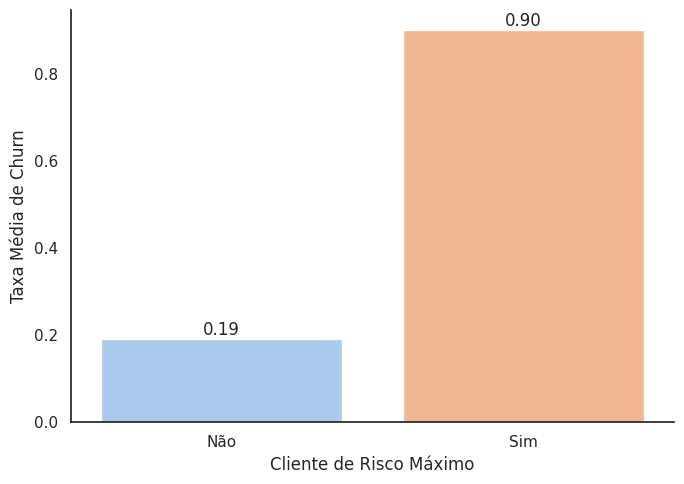

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

ax = sns.barplot(

    x="ClienteRiscoMaximo",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

ax.set_xticklabels([
    "Não",
    "Sim"
])

plt.xlabel("Cliente de Risco Máximo")
plt.ylabel("Taxa Média de Churn")

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_21533/4001379478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_21533/4001379478.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


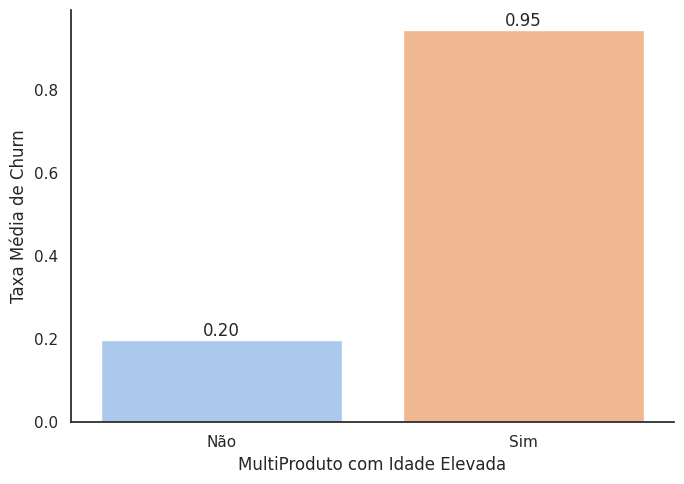

In [66]:
plt.figure(figsize=(7,5))

ax = sns.barplot(

    x="MultiProdutoIdadeAlta",

    y="Churn",

    data=df,

    estimator=lambda x: sum(x)/len(x),

    palette="pastel",

    errorbar=None
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(

        f'{altura:.2f}',

        (
            p.get_x() + p.get_width()/2,
            altura
        ),

        ha='center',

        va='bottom'
    )

ax.set_xticklabels([
    "Não",
    "Sim"
])

plt.xlabel("MultiProduto com Idade Elevada")
plt.ylabel("Taxa Média de Churn")

sns.despine()

plt.tight_layout()

plt.show()

In [67]:
df = df.drop(columns=["Reclamacao"])

#### Avaliar correlação das variáveis

In [68]:
df.head(1)

,PontuacaoCredito,Localizacao,Genero,Idade,TempoRelacionamento,Saldo,NumeroProdutos,PossuiCartaoCredito,MembroAtivo,SalarioEstimado,...,FaixaSaldo,SemSaldo,SaldoAlto,MultiProduto,PerfilIdealProdutos,FaixaSalario,FaixaPontos,ClienteRiscoMaximo,MultiProdutoAlemanha,MultiProdutoIdadeAlta
0,619,France,Female,42,2,0.0,1,1,1,101348.88,...,Zero,1,0,0,0,"(80238.34, 119710.038]","(452.0, 529.0]",0,0,0


In [69]:
df_vif = df.drop(columns=["Churn", "Localizacao", "TipoCartao", "Genero", "RiscoCredito", "FaixaEtaria", "FaixaPontos", "FaixaSaldo", "FaixaSalario", "PerfilIdealProdutos", "SemSaldo", "SaldoAlto", "ClienteAntigo", "ClienteNovo", "IdadeAltoChurn",
"MultiProdutoIdadeAlta", "MultiProduto", "PontuacaoCredito"])

In [70]:
df_vif.head(1)

,Idade,TempoRelacionamento,Saldo,NumeroProdutos,PossuiCartaoCredito,MembroAtivo,SalarioEstimado,NivelSatisfacao,PontosAcumulados,ClienteRiscoMaximo,MultiProdutoAlemanha
0,42,2,0.0,1,1,1,101348.88,2,464,0,0


In [71]:
df_vif = df_vif.astype(float)

In [72]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Variavel"] = df_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(df_vif.values, i)
    for i in range(df_vif.shape[1])
]

vif_data.sort_values(by="VIF", ascending=False)

,Variavel,VIF
0,Idade,10.660856
3,NumeroProdutos,8.119630
8,PontosAcumulados,6.976853
7,NivelSatisfacao,5.045254
6,SalarioEstimado,3.796025
1,TempoRelacionamento,3.786253
4,PossuiCartaoCredito,3.218871
2,Saldo,2.570272
5,MembroAtivo,2.128511
9,ClienteRiscoMaximo,1.429184


In [73]:
# df_vif = df_vif.drop(columns=["PontuacaoCredito"])

Foi realizada a análise de multicolinearidade por meio do cálculo do Variance Inflation Factor (VIF). 
Inicialmente, algumas variáveis apresentaram valores elevados de VIF, indicando possível colinearidade. 
Entretanto, optou-se por manter variáveis com relevância teórica, como a idade, mesmo com valores mais elevados, uma vez que sua exclusão poderia comprometer a capacidade explicativa do modelo. 
Após a remoção de variáveis redundantes, os valores de VIF permaneceram em níveis aceitáveis, não indicando multicolinearidade severa.

In [74]:
df.head(1)

,PontuacaoCredito,Localizacao,Genero,Idade,TempoRelacionamento,Saldo,NumeroProdutos,PossuiCartaoCredito,MembroAtivo,SalarioEstimado,...,FaixaSaldo,SemSaldo,SaldoAlto,MultiProduto,PerfilIdealProdutos,FaixaSalario,FaixaPontos,ClienteRiscoMaximo,MultiProdutoAlemanha,MultiProdutoIdadeAlta
0,619,France,Female,42,2,0.0,1,1,1,101348.88,...,Zero,1,0,0,0,"(80238.34, 119710.038]","(452.0, 529.0]",0,0,0


In [75]:
df_cor = df.drop(columns=["Localizacao", "TipoCartao", "Genero", "FaixaPontos", "RiscoCredito", "FaixaEtaria", "FaixaSaldo", "FaixaSalario"])
df_cor.corr()["Churn"].sort_values(ascending=False)

Churn                    1.000000
IdadeAltoChurn           0.347626
MultiProduto             0.298536
Idade                    0.285296
ClienteRiscoMaximo       0.237365
MultiProdutoAlemanha     0.195033
MultiProdutoIdadeAlta    0.177462
Saldo                    0.118577
SaldoAlto                0.115759
SalarioEstimado          0.012490
ClienteNovo              0.011079
PontosAcumulados        -0.004628
NivelSatisfacao         -0.005849
PossuiCartaoCredito     -0.006976
TempoRelacionamento     -0.013656
ClienteAntigo           -0.015484
PontuacaoCredito        -0.026771
NumeroProdutos          -0.047611
SemSaldo                -0.122522
MembroAtivo             -0.156356
PerfilIdealProdutos     -0.292151
Name: Churn, dtype: float64

A variável número de produtos apresentou baixa correlação linear com churn. Entretanto, após transformação não linear para identificação de clientes com três ou mais produtos, observou-se aumento significativo da associação com a variável alvo.

#### Importância das variáveis

In [76]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

df_imp = df.drop(columns=["Localizacao", "TipoCartao", "Genero", "FaixaPontos", "RiscoCredito", "FaixaEtaria", "FaixaSaldo", "FaixaSalario"])

# Definir X e y
X = df_imp.drop("Churn", axis=1)
y = df_imp["Churn"]

# Modelo
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Importância
importancias = pd.Series(rf.feature_importances_, index=X.columns)

# Ordenar
importancias.sort_values(ascending=False)

Idade                    0.152932
PontosAcumulados         0.116275
SalarioEstimado          0.116074
PontuacaoCredito         0.113612
Saldo                    0.100350
IdadeAltoChurn           0.068805
TempoRelacionamento      0.056745
PerfilIdealProdutos      0.046949
NivelSatisfacao          0.045040
NumeroProdutos           0.040511
MembroAtivo              0.036592
MultiProduto             0.026984
PossuiCartaoCredito      0.015996
ClienteRiscoMaximo       0.015236
ClienteAntigo            0.010048
SemSaldo                 0.009846
SaldoAlto                0.009552
ClienteNovo              0.009261
MultiProdutoAlemanha     0.006466
MultiProdutoIdadeAlta    0.002722
dtype: float64

Algumas variáveis apresentaram baixa correlação linear com churn, porém elevada importância nos modelos baseados em árvores, evidenciando relações não lineares e interações complexas entre atributos.

In [77]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X, y, n_repeats=10, random_state=42)

importancias_perm = pd.Series(result.importances_mean, index=X.columns)

importancias_perm.sort_values(ascending=False)

Idade                    0.13029
MembroAtivo              0.08377
PerfilIdealProdutos      0.06357
Saldo                    0.05592
SalarioEstimado          0.05175
PontosAcumulados         0.05108
PontuacaoCredito         0.04752
IdadeAltoChurn           0.04224
TempoRelacionamento      0.04136
NivelSatisfacao          0.03842
PossuiCartaoCredito      0.02527
SaldoAlto                0.02075
SemSaldo                 0.01985
NumeroProdutos           0.01780
ClienteAntigo            0.01557
ClienteNovo              0.01245
MultiProduto             0.00407
MultiProdutoAlemanha     0.00099
ClienteRiscoMaximo       0.00027
MultiProdutoIdadeAlta    0.00000
dtype: float64

Observou-se que determinadas variáveis apresentaram baixa correlação linear com churn, porém elevada importância por permutação, indicando a existência de relações não lineares e interações complexas capturadas pelos modelos baseados em árvores.

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

coef = pd.Series(model.coef_[0], index=X.columns)

coef.sort_values(ascending=False)

NumeroProdutos           1.078518
IdadeAltoChurn           0.507685
Idade                    0.479868
SaldoAlto                0.204475
MultiProdutoAlemanha     0.073657
ClienteNovo              0.043211
TempoRelacionamento      0.034954
SalarioEstimado          0.027021
PossuiCartaoCredito     -0.015944
PontosAcumulados        -0.022412
ClienteRiscoMaximo      -0.022994
MultiProdutoIdadeAlta   -0.031948
NivelSatisfacao         -0.033028
PontuacaoCredito        -0.054843
ClienteAntigo           -0.070972
SemSaldo                -0.131889
Saldo                   -0.166620
MultiProduto            -0.176416
MembroAtivo             -0.537048
PerfilIdealProdutos     -1.610283
dtype: float64

Observou-se comportamento não linear associado ao número de produtos contratados. Enquanto o aumento geral no número de produtos elevou a propensão ao churn, clientes com exatamente dois produtos apresentaram forte redução da probabilidade de evasão.

A análise dos coeficientes da regressão logística permitiu identificar os principais fatores associados ao churn de clientes.

A variável reclamação apresentou o maior coeficiente positivo, indicando forte influência no aumento da probabilidade de evasão. Esse resultado sugere que clientes que registram reclamações possuem significativamente maior tendência a encerrar seu relacionamento com a instituição.

A variável idade também apresentou coeficiente positivo relevante, indicando que, neste conjunto de dados, clientes mais velhos apresentam maior probabilidade de churn.

Por outro lado, variáveis relacionadas ao engajamento e relacionamento com o banco apresentaram coeficientes negativos, indicando redução na probabilidade de evasão. Destacam-se as variáveis membro ativo, pontos acumulados e nível de satisfação, evidenciando que clientes mais engajados e satisfeitos tendem a permanecer na instituição.

Além disso, o número de produtos contratados e o tempo de relacionamento também contribuem para a retenção, ainda que com menor intensidade.

Esses resultados indicam que fatores comportamentais e de satisfação possuem maior impacto no churn do que variáveis financeiras, como saldo e salário estimado.

#### Váriaveis não númericas

In [79]:
df_dummy = pd.get_dummies(
    df,
    columns=["Localizacao", "TipoCartao", "FaixaPontos", "RiscoCredito", "FaixaEtaria", "FaixaSaldo", "FaixaSalario"],
    drop_first=True
)


df_dummy["Genero"] = df_dummy["Genero"].map({"Male": 0, "Female": 1})

In [80]:
from sklearn.ensemble import RandomForestClassifier

X_dummy = df_dummy.drop("Churn", axis=1)
y_dummy = df_dummy["Churn"]

rf = RandomForestClassifier(random_state=42)
rf.fit(X_dummy, y_dummy)

importancias = pd.Series(rf.feature_importances_, index=X_dummy.columns)
importancias.sort_values(ascending=False)

Idade                                    0.100627
SalarioEstimado                          0.070178
PontosAcumulados                         0.069670
PontuacaoCredito                         0.069372
Saldo                                    0.066082
IdadeAltoChurn                           0.050345
NumeroProdutos                           0.047917
TempoRelacionamento                      0.043083
PerfilIdealProdutos                      0.041264
MembroAtivo                              0.035205
NivelSatisfacao                          0.032269
MultiProduto                             0.026834
Localizacao_Germany                      0.023537
FaixaEtaria_Senior                       0.020449
FaixaEtaria_Meia_Idade                   0.016468
Genero                                   0.014817
PossuiCartaoCredito                      0.012320
TipoCartao_SILVER                        0.011270
ClienteRiscoMaximo                       0.011116
Localizacao_Spain                        0.010939


Clientes localizados na Alemanha apresentaram maior relevância preditiva para churn quando comparados aos demais países, indicando possível influência regional no comportamento de evasão

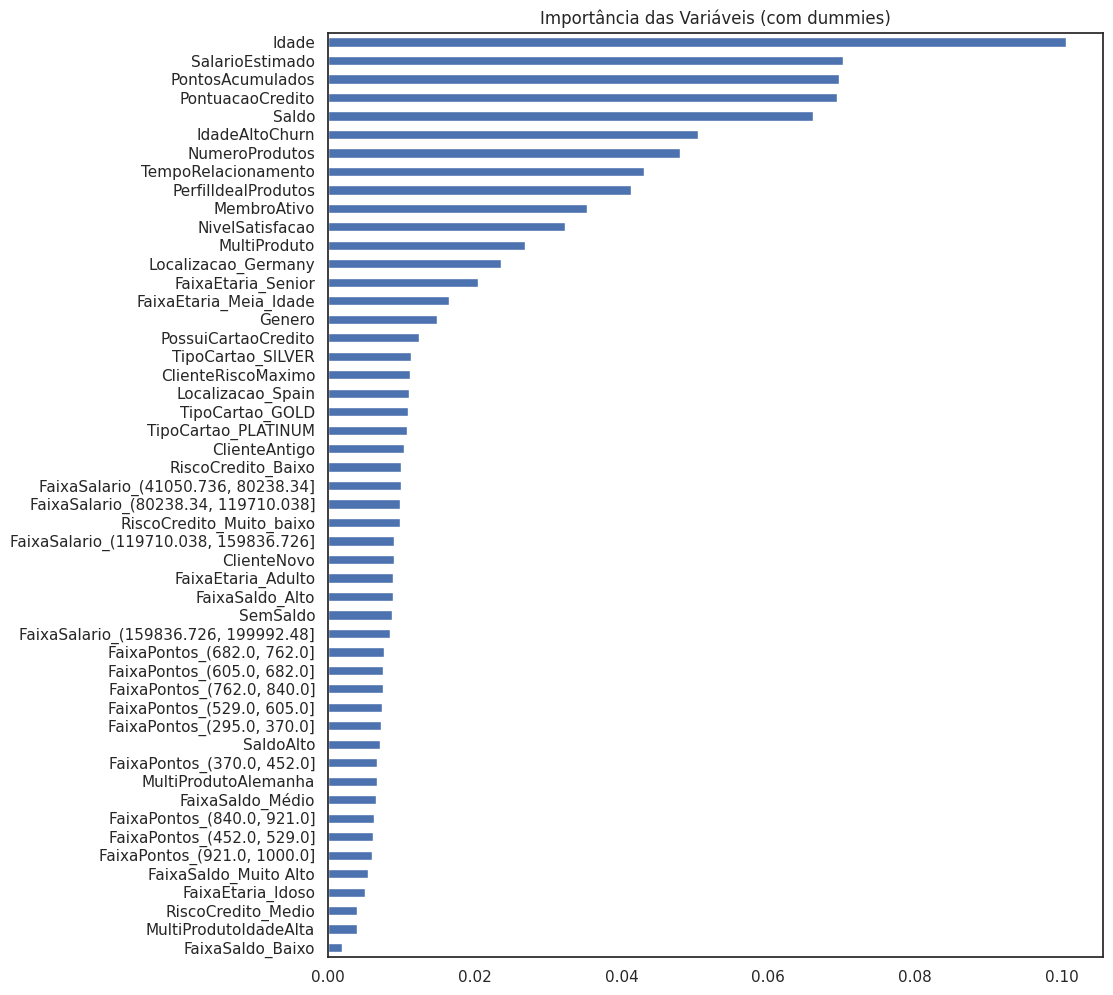

In [81]:
importancias.sort_values().plot(kind="barh", figsize=(10,12))
plt.title("Importância das Variáveis (com dummies)")
plt.show()

#### Seleção de variáveis

In [82]:
from sklearn.feature_selection import SelectKBest, f_classif

# Definir X e y
X = df_dummy.drop("Churn", axis=1)
y = df_dummy["Churn"]

selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X, y)

scores = pd.Series(selector.scores_, index=X.columns)

scores.sort_values(ascending=False)

IdadeAltoChurn                           1374.264183
MultiProduto                              978.247039
PerfilIdealProdutos                       932.981396
Idade                                     885.883609
FaixaEtaria_Senior                        735.452746
ClienteRiscoMaximo                        596.941103
MultiProdutoAlemanha                      395.338998
FaixaEtaria_Meia_Idade                    355.754694
FaixaEtaria_Adulto                        349.878158
MultiProdutoIdadeAlta                     325.102619
Localizacao_Germany                       309.612123
MembroAtivo                               250.547093
SemSaldo                                  152.373270
Saldo                                     142.581456
SaldoAlto                                 135.795400
Genero                                    114.192705
FaixaSaldo_Alto                           112.375056
Localizacao_Spain                          27.950315
NumeroProdutos                             22.

Algumas variáveis apresentaram baixa relevância em testes univariados lineares, mas elevada importância em modelos baseados em árvores, indicando relações não lineares e dependências multivariadas.

In [83]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

X_scaled = scaler.fit_transform(X)

rfe = RFE(model, n_features_to_select=5)
rfe.fit(X_scaled, y)

selecionadas = pd.Series(rfe.support_, index=X.columns)
selecionadas

PontuacaoCredito                         False
Genero                                   False
Idade                                    False
TempoRelacionamento                      False
Saldo                                    False
NumeroProdutos                            True
PossuiCartaoCredito                      False
MembroAtivo                              False
SalarioEstimado                          False
NivelSatisfacao                          False
PontosAcumulados                         False
IdadeAltoChurn                           False
ClienteNovo                              False
ClienteAntigo                            False
SemSaldo                                 False
SaldoAlto                                False
MultiProduto                             False
PerfilIdealProdutos                       True
ClienteRiscoMaximo                       False
MultiProdutoAlemanha                     False
MultiProdutoIdadeAlta                    False
Localizacao_G

Observou-se diferença entre os atributos selecionados por métodos lineares e modelos baseados em árvores. Variáveis financeiras contínuas apresentaram maior relevância nos modelos ensemble, enquanto variáveis relacionadas ao comportamento e engajamento foram priorizadas pelos métodos lineares.

Para a seleção de variáveis, foram utilizadas diferentes abordagens, incluindo métodos estatísticos e baseados em modelos, como SelectKBest e Recursive Feature Elimination (RFE). 

Além disso, variáveis categóricas foram analisadas por meio de tabelas de contingência e técnicas de associação, permitindo avaliar sua relação com a variável alvo.

Os resultados mostraram consistência entre os métodos, destacando variáveis comportamentais, como reclamação e atividade do cliente, como os principais fatores associados ao churn. 

Essa abordagem combinada permitiu uma seleção mais robusta das variáveis, considerando tanto aspectos estatísticos quanto interpretabilidade do modelo.

Variáveis escolhidas:

- Saldo
- Idade
- MembroAtivo
- NumeroProdutos
- PontosAcumulados

Com base na análise conjunta de diferentes métodos de seleção de variáveis, incluindo importância em modelos de aprendizado de máquina, coeficientes da regressão logística, SelectKBest e Recursive Feature Elimination (RFE), foi definido um conjunto final de variáveis para o modelo.

As variáveis selecionadas foram: reclamação, idade, atividade do cliente, número de produtos, nível de satisfação e pontos acumulados.

Essas variáveis foram escolhidas por apresentarem consistência entre os métodos utilizados e por representarem dimensões relevantes do comportamento do cliente, incluindo insatisfação, engajamento e características individuais.

#### Escolha das Features

In [84]:
# features escolhidas
features = [

    "PontuacaoCredito",
    "Saldo",
    "SalarioEstimado",
    "PontosAcumulados",

    "TempoRelacionamento",
    # "NumeroProdutos",

    "MembroAtivo",
    "PossuiCartaoCredito",

    "Idade",

    "IdadeAltoChurn",
    "PerfilIdealProdutos",
    "MultiProduto",
]

target = "Churn"

In [85]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


# dataframe VIF
X_vif = df[features].copy()

# adicionar constante
X_vif = add_constant(X_vif)

# calcular VIF
vif = pd.DataFrame()

vif["Variavel"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# remover constante
vif = vif[vif["Variavel"] != "const"]

# ordenar
vif.sort_values(by="VIF", ascending=False)

,Variavel,VIF
8,Idade,1.410007
9,IdadeAltoChurn,1.404876
10,PerfilIdealProdutos,1.205974
2,Saldo,1.157097
11,MultiProduto,1.040604
6,MembroAtivo,1.014366
5,TempoRelacionamento,1.001754
1,PontuacaoCredito,1.001434
7,PossuiCartaoCredito,1.001256
3,SalarioEstimado,1.001064


Após análise de multicolinearidade via VIF, optou-se pela remoção da variável original relacionada ao número de produtos, mantendo-se apenas atributos derivados mais representativos e interpretáveis.

In [86]:
df.head(1)

,PontuacaoCredito,Localizacao,Genero,Idade,TempoRelacionamento,Saldo,NumeroProdutos,PossuiCartaoCredito,MembroAtivo,SalarioEstimado,...,FaixaSaldo,SemSaldo,SaldoAlto,MultiProduto,PerfilIdealProdutos,FaixaSalario,FaixaPontos,ClienteRiscoMaximo,MultiProdutoAlemanha,MultiProdutoIdadeAlta
0,619,France,Female,42,2,0.0,1,1,1,101348.88,...,Zero,1,0,0,0,"(80238.34, 119710.038]","(452.0, 529.0]",0,0,0


#### Modelo

Imports

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

In [88]:
num_features = [

    "PontuacaoCredito",
    "Saldo",
    "SalarioEstimado",
    "PontosAcumulados",

    "TempoRelacionamento",

    "Idade"
]

cat_features = [

    "Genero",
    "Localizacao",

    "MembroAtivo",
    "PossuiCartaoCredito",

    "IdadeAltoChurn",
    "PerfilIdealProdutos",
    "MultiProduto"
]

In [89]:
def avaliar(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [90]:
def avaliar_modelo(nome, y_test, y_pred, y_prob):

    print(f"===== {nome} =====")

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-Score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

    print()

Pipeline

In [91]:
num_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

Regressão Logistica

In [92]:
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]

In [93]:
categorical_features = (
    X.select_dtypes(
        include=["object", "category"]
    ).columns
)

numerical_features = (
    X.select_dtypes(
        exclude=["object", "category"]
    ).columns
)

/tmp/ipykernel_21533/796223898.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(


In [94]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [95]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)

In [96]:
from sklearn.linear_model import LogisticRegression

log_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

log_pipeline.fit(X_train, y_train)

y_pred_log = log_pipeline.predict(X_test)
y_prob_log = log_pipeline.predict_proba(X_test)[:, 1]

res = avaliar(log_pipeline, X_test, y_test)
res

{'Accuracy': 0.8655,
 'Precision': 0.7602996254681648,
 'Recall': 0.49754901960784315,
 'F1': 0.6014814814814815,
 'ROC-AUC': 0.8591456054783723}

Random Forest

In [97]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

res = avaliar(rf_pipeline, X_test, y_test)
res

{'Accuracy': 0.8615,
 'Precision': 0.7673469387755102,
 'Recall': 0.46078431372549017,
 'F1': 0.5758039816232772,
 'ROC-AUC': 0.8652730564587643}

XGBOOST

In [98]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [99]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("model", XGBClassifier(

        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,

        subsample=0.8,
        colsample_bytree=0.8,

        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

res = avaliar(xgb_pipeline, X_test, y_test)
res

{'Accuracy': 0.8695,
 'Precision': 0.7712177121771218,
 'Recall': 0.5122549019607843,
 'F1': 0.6156111929307806,
 'ROC-AUC': 0.8724135382796334}

Instalacoes

In [100]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [101]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from catboost import CatBoostClassifier

from lightgbm import LGBMClassifier

Decision Tree

In [102]:
dt_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("model", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

res = avaliar(dt_pipeline, X_test, y_test)
res

{'Accuracy': 0.858,
 'Precision': 0.7649572649572649,
 'Recall': 0.4387254901960784,
 'F1': 0.557632398753894,
 'ROC-AUC': 0.8407686409991131}

Extra Trees

In [103]:
et_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("model", ExtraTreesClassifier(

        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

et_pipeline.fit(X_train, y_train)

y_pred_et = et_pipeline.predict(X_test)
y_prob_et = et_pipeline.predict_proba(X_test)[:, 1]

res = avaliar(et_pipeline, X_test, y_test)
res

{'Accuracy': 0.859,
 'Precision': 0.7386363636363636,
 'Recall': 0.47794117647058826,
 'F1': 0.5803571428571429,
 'ROC-AUC': 0.8555091634643808}

CATBOOST

In [104]:
cat_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("model", CatBoostClassifier(

        iterations=300,
        learning_rate=0.05,
        depth=5,

        verbose=0,
        random_state=42
    ))
])

cat_pipeline.fit(X_train, y_train)

y_pred_cat = cat_pipeline.predict(X_test)
y_prob_cat = cat_pipeline.predict_proba(X_test)[:, 1]

res = avaliar(cat_pipeline, X_test, y_test)
res

{'Accuracy': 0.869,
 'Precision': 0.7744360902255639,
 'Recall': 0.5049019607843137,
 'F1': 0.6112759643916914,
 'ROC-AUC': 0.8791337200709428}

LIGHTGBM

In [105]:
lgbm_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("model", LGBMClassifier(

        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,

        random_state=42
    ))
])

lgbm_pipeline.fit(X_train, y_train)

y_pred_lgbm = lgbm_pipeline.predict(X_test)
y_prob_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

res = avaliar(lgbm_pipeline, X_test, y_test)
res

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001218 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1218
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/home/karine/Área de trabalho/TCC/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/karine/Área de trabalho/TCC/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/karine/Área de trabalho/TCC/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/karine/Área de trabalho/TCC/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'Accuracy': 0.8635,
 'Precision': 0.7419354838709677,
 'Recall': 0.5073529411764706,
 'F1': 0.6026200873362445,
 'ROC-AUC': 0.874205586757316}

Tunning

LOGISTIC REGRESSION BALANCED

In [106]:
log_bal_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("model", LogisticRegression(

        max_iter=2000,
        random_state=42,

        class_weight="balanced"
    ))
])

log_bal_pipeline.fit(X_train, y_train)

y_pred_log_bal = log_bal_pipeline.predict(X_test)
y_prob_log_bal = log_bal_pipeline.predict_proba(X_test)[:, 1]

res = avaliar(log_bal_pipeline, X_test, y_test)
res

{'Accuracy': 0.785,
 'Precision': 0.48297213622291024,
 'Recall': 0.7647058823529411,
 'F1': 0.5920303605313093,
 'ROC-AUC': 0.8592071879002856}

RANDOM FOREST BALANCED

In [107]:
rf_bal_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("model", RandomForestClassifier(

        n_estimators=300,

        random_state=42,
        n_jobs=-1,

        class_weight="balanced"
    ))
])

rf_bal_pipeline.fit(X_train, y_train)

y_pred_rf_bal = rf_bal_pipeline.predict(X_test)
y_prob_rf_bal = rf_bal_pipeline.predict_proba(X_test)[:, 1]

res = avaliar(rf_bal_pipeline, X_test, y_test)
res

{'Accuracy': 0.862,
 'Precision': 0.8027522935779816,
 'Recall': 0.42892156862745096,
 'F1': 0.5591054313099042,
 'ROC-AUC': 0.8685169105330575}

DECISION TREE BALANCED

In [108]:
dt_bal_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("model", DecisionTreeClassifier(

        max_depth=5,

        random_state=42,

        class_weight="balanced"
    ))
])

dt_bal_pipeline.fit(X_train, y_train)

y_pred_dt_bal = dt_bal_pipeline.predict(X_test)
y_prob_dt_bal = dt_bal_pipeline.predict_proba(X_test)[:, 1]

res = avaliar(dt_bal_pipeline, X_test, y_test)
res

{'Accuracy': 0.756,
 'Precision': 0.4445983379501385,
 'Recall': 0.7867647058823529,
 'F1': 0.5681415929203539,
 'ROC-AUC': 0.8467544524091043}

In [109]:
avaliar_modelo(
    "Logistic Balanced",
    y_test,
    y_pred_log_bal,
    y_prob_log_bal
)

avaliar_modelo(
    "RF Balanced",
    y_test,
    y_pred_rf_bal,
    y_prob_rf_bal
)

avaliar_modelo(
    "DT Balanced",
    y_test,
    y_pred_dt_bal,
    y_prob_dt_bal
)

===== Logistic Balanced =====
Accuracy : 0.785
Precision: 0.48297213622291024
Recall   : 0.7647058823529411
F1-Score : 0.5920303605313093
ROC-AUC  : 0.8592071879002856

===== RF Balanced =====
Accuracy : 0.862
Precision: 0.8027522935779816
Recall   : 0.42892156862745096
F1-Score : 0.5591054313099042
ROC-AUC  : 0.8685169105330575

===== DT Balanced =====
Accuracy : 0.756
Precision: 0.4445983379501385
Recall   : 0.7867647058823529
F1-Score : 0.5681415929203539
ROC-AUC  : 0.8467544524091043



In [110]:
from sklearn.model_selection import RandomizedSearchCV

XGBOOST TUNING

In [111]:
# PARÂMETROS
xgb_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

y_pred_xgb_best = best_xgb.predict(X_test)
y_prob_xgb_best = best_xgb.predict_proba(X_test)[:, 1]

res = avaliar(best_xgb, X_test, y_test)
res

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'Accuracy': 0.871,
 'Precision': 0.7862595419847328,
 'Recall': 0.5049019607843137,
 'F1': 0.6149253731343284,
 'ROC-AUC': 0.8785101980490688}

In [112]:
avaliar_modelo(
    "XGBoost Tunado",
    y_test,
    y_pred_xgb_best,
    y_prob_xgb_best
)

===== XGBoost Tunado =====
Accuracy : 0.871
Precision: 0.7862595419847328
Recall   : 0.5049019607843137
F1-Score : 0.6149253731343284
ROC-AUC  : 0.8785101980490688



CATBOOST TUNING

In [113]:
cat_params = {

    "model__iterations": [100, 200, 300, 500],

    "model__depth": [3, 4, 5, 6, 8],

    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],

    "model__l2_leaf_reg": [1, 3, 5, 7, 9]
}

cat_search = RandomizedSearchCV(
    estimator=cat_pipeline,
    param_distributions=cat_params,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

cat_search.fit(X_train, y_train)
best_cat = cat_search.best_estimator_

y_pred_cat_best = best_cat.predict(X_test)
y_prob_cat_best = best_cat.predict_proba(X_test)[:, 1]

res = avaliar(best_cat, X_test, y_test)
res

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'Accuracy': 0.8715,
 'Precision': 0.7827715355805244,
 'Recall': 0.5122549019607843,
 'F1': 0.6192592592592593,
 'ROC-AUC': 0.882359099418662}

In [114]:
avaliar_modelo(
    "CatBoost Tunado",
    y_test,
    y_pred_cat_best,
    y_prob_cat_best
)

===== CatBoost Tunado =====
Accuracy : 0.8715
Precision: 0.7827715355805244
Recall   : 0.5122549019607843
F1-Score : 0.6192592592592593
ROC-AUC  : 0.882359099418662



Testar mudar o Treshold

In [115]:
y_prob = y_prob_cat_best

threshold = 0.3

y_pred_new = (y_prob >= threshold).astype(int)

avaliar_modelo(
    "CatBoost Threshold 0.3",
    y_test,
    y_pred_new,
    y_prob
)

===== CatBoost Threshold 0.3 =====
Accuracy : 0.845
Precision: 0.6074561403508771
Recall   : 0.678921568627451
F1-Score : 0.6412037037037037
ROC-AUC  : 0.882359099418662



In [116]:
for t in [0.2, 0.3, 0.35, 0.4, 0.45, 0.5]:

    y_pred_t = (y_prob >= t).astype(int)

    print(f"\nThreshold: {t}")

    print(
        "Recall:",
        recall_score(y_test, y_pred_t)
    )

    print(
        "Precision:",
        precision_score(y_test, y_pred_t)
    )

    print(
        "F1:",
        f1_score(y_test, y_pred_t)
    )


Threshold: 0.2
Recall: 0.7941176470588235
Precision: 0.5118483412322274
F1: 0.622478386167147

Threshold: 0.3
Recall: 0.678921568627451
Precision: 0.6074561403508771
F1: 0.6412037037037037

Threshold: 0.35
Recall: 0.625
Precision: 0.6521739130434783
F1: 0.6382978723404256

Threshold: 0.4
Recall: 0.5808823529411765
Precision: 0.688953488372093
F1: 0.6303191489361702

Threshold: 0.45
Recall: 0.5343137254901961
Precision: 0.7414965986394558
F1: 0.6210826210826211

Threshold: 0.5
Recall: 0.5122549019607843
Precision: 0.7827715355805244
F1: 0.6192592592592593


Métricas

In [117]:
from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def avaliar_modelo(nome, y_test, y_pred, y_prob):

    print(f"===== {nome} =====")

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-Score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

    print()

avaliar_modelo(
    "Logistic Regression",
    y_test,
    y_pred_log,
    y_prob_log
)

avaliar_modelo(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

avaliar_modelo(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

===== Logistic Regression =====
Accuracy : 0.8655
Precision: 0.7602996254681648
Recall   : 0.49754901960784315
F1-Score : 0.6014814814814815
ROC-AUC  : 0.8591456054783723

===== Random Forest =====
Accuracy : 0.8615
Precision: 0.7673469387755102
Recall   : 0.46078431372549017
F1-Score : 0.5758039816232772
ROC-AUC  : 0.8652730564587643

===== XGBoost =====
Accuracy : 0.8695
Precision: 0.7712177121771218
Recall   : 0.5122549019607843
F1-Score : 0.6156111929307806
ROC-AUC  : 0.8724135382796334



Matriz de Confusão

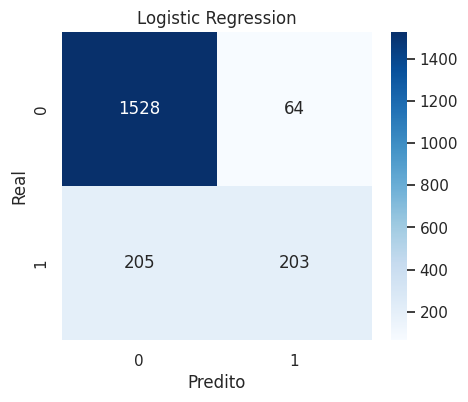

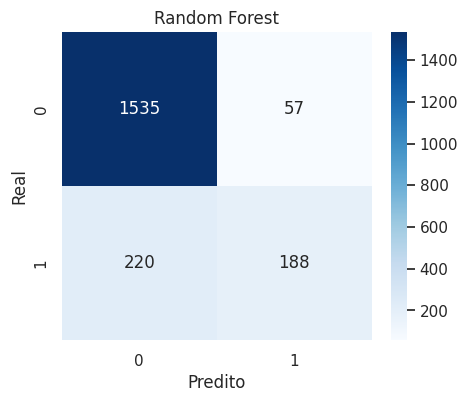

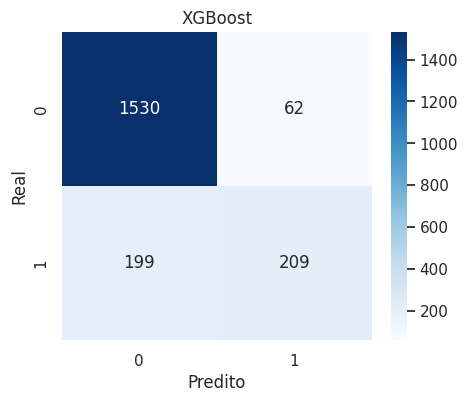

In [118]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_test, y_pred, titulo):

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(titulo)

    plt.xlabel("Predito")
    plt.ylabel("Real")

    plt.show()

plot_confusion_matrix(
    y_test,
    y_pred_log,
    "Logistic Regression"
)

plot_confusion_matrix(
    y_test,
    y_pred_rf,
    "Random Forest"
)

plot_confusion_matrix(
    y_test,
    y_pred_xgb,
    "XGBoost"
)

ROC CURVE

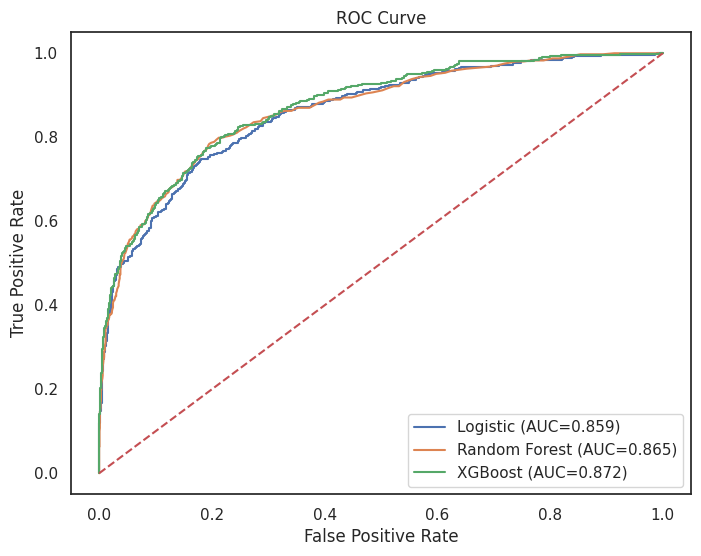

In [119]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for nome, y_prob in [

    ("Logistic", y_prob_log),
    ("Random Forest", y_prob_rf),
    ("XGBoost", y_prob_xgb)

]:

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{nome} (AUC={auc:.3f})"
    )

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

Cross Validation

In [120]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(

    best_cat,

    X,
    y,

    cv=5,

    scoring="roc_auc",

    n_jobs=-1
)

print("ROC-AUC em cada fold:")
print(scores)

print("\nROC-AUC médio:")
print(scores.mean())

print("\nDesvio padrão:")
print(scores.std())

ROC-AUC em cada fold:
[0.87074004 0.87437494 0.86870474 0.87346514 0.86712753]

ROC-AUC médio:
0.8708824768195338

Desvio padrão:
0.002746996220041336


FEATURE IMPORTANCE FINAL DO CATBOOST

In [121]:
import pandas as pd
import matplotlib.pyplot as plt

# pegar modelo treinado
cat_model = best_cat.named_steps["model"]

# pegar nomes das features após preprocessamento
feature_names = best_cat.named_steps[
    "preprocessor"
].get_feature_names_out()

# importâncias
importancias = pd.Series(

    cat_model.feature_importances_,

    index=feature_names
)

# ordenar
importancias = importancias.sort_values(
    ascending=False
)

# mostrar top 15
print(importancias.head(15))

num__Idade                  17.200410
num__PerfilIdealProdutos    15.716212
num__NumeroProdutos         10.501415
cat__Localizacao_Germany     8.594954
num__MembroAtivo             7.867760
num__Saldo                   7.687576
num__IdadeAltoChurn          7.016407
num__MultiProduto            6.121798
cat__FaixaSaldo_Zero         2.570121
cat__FaixaSaldo_Alto         2.229067
num__SalarioEstimado         1.933598
num__PontuacaoCredito        1.793115
cat__FaixaEtaria_Senior      1.452119
cat__Genero_Female           1.240341
cat__Genero_Male             1.212457
dtype: float64


/tmp/ipykernel_21533/2141398258.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


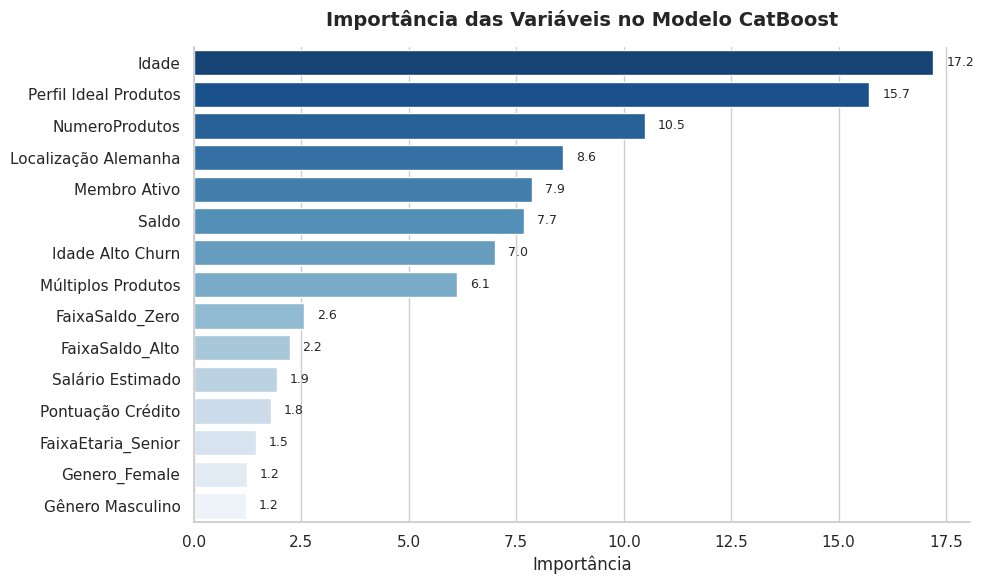

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# MODELO TREINADO
# =========================

cat_model = best_cat.named_steps["model"]

# =========================
# NOMES DAS VARIÁVEIS
# =========================

feature_names = best_cat.named_steps[
    "preprocessor"
].get_feature_names_out()

# Limpar nomes
feature_names = [

    nome.replace("num__", "")
        .replace("cat__", "")
        .replace("_1", "")
        .replace("Idade", "Idade")
        .replace("Saldo", "Saldo")
        .replace("MembroAtivo", "Membro Ativo")
        .replace("PerfilIdealProdutos", "Perfil Ideal Produtos")
        .replace("MultiProduto", "Múltiplos Produtos")
        .replace("Genero_Male", "Gênero Masculino")
        .replace("Localizacao_Germany", "Localização Alemanha")
        .replace("Localizacao_Spain", "Localização Espanha")
        .replace("PontuacaoCredito", "Pontuação Crédito")
        .replace("SalarioEstimado", "Salário Estimado")
        .replace("TempoRelacionamento", "Tempo Relacionamento")
        .replace("PossuiCartaoCredito", "Possui Cartão Crédito")
        .replace("PontosAcumulados", "Pontos Acumulados")
        .replace("IdadeAltoChurn", "Idade Alto Churn")

    for nome in feature_names
]

# =========================
# IMPORTÂNCIA DAS VARIÁVEIS
# =========================

importancias = pd.Series(

    cat_model.feature_importances_,

    index=feature_names
)

# Ordenar
importancias = importancias.sort_values(
    ascending=False
)

# =========================
# PLOT
# =========================

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

ax = sns.barplot(

    x=importancias.head(15).values,

    y=importancias.head(15).index,

    palette="Blues_r"
)

# Adicionar valores
for i, valor in enumerate(
    importancias.head(15).values
):

    ax.text(

        valor + 0.3,

        i,

        f"{valor:.1f}",

        va='center',

        fontsize=9
    )

plt.title(

    "Importância das Variáveis no Modelo CatBoost",

    fontsize=14,

    fontweight='bold',

    pad=15
)

plt.xlabel(
    "Importância",
    fontsize=12
)

plt.ylabel("")

sns.despine()

plt.tight_layout()

plt.show()

CLASSIFICATION REPORT

In [123]:
from sklearn.metrics import classification_report

print(

    classification_report(
        y_test,
        y_pred_cat_best
    )
)

              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1592
           1       0.78      0.51      0.62       408

    accuracy                           0.87      2000
   macro avg       0.83      0.74      0.77      2000
weighted avg       0.86      0.87      0.86      2000



In [124]:
print(

    classification_report(

        y_test,

        y_pred_cat_best,

        target_names=[
            "Nao Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

   Nao Churn       0.89      0.96      0.92      1592
       Churn       0.78      0.51      0.62       408

    accuracy                           0.87      2000
   macro avg       0.83      0.74      0.77      2000
weighted avg       0.86      0.87      0.86      2000



In [125]:
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

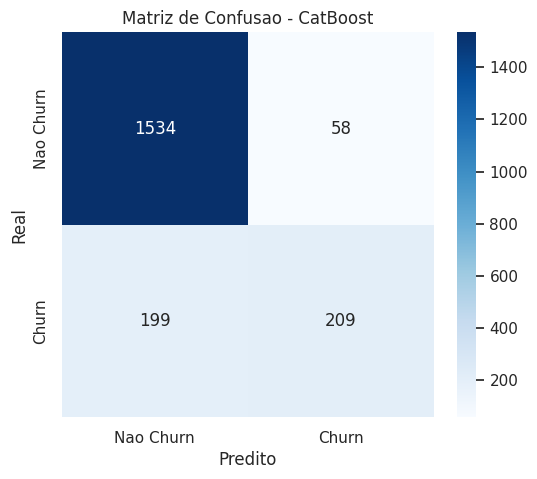

In [126]:
cm = confusion_matrix(
    y_test,
    y_pred_cat_best
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Nao Churn",
        "Churn"
    ],

    yticklabels=[
        "Nao Churn",
        "Churn"
    ]
)

plt.title(
    "Matriz de Confusao - CatBoost"
)

plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()

In [127]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

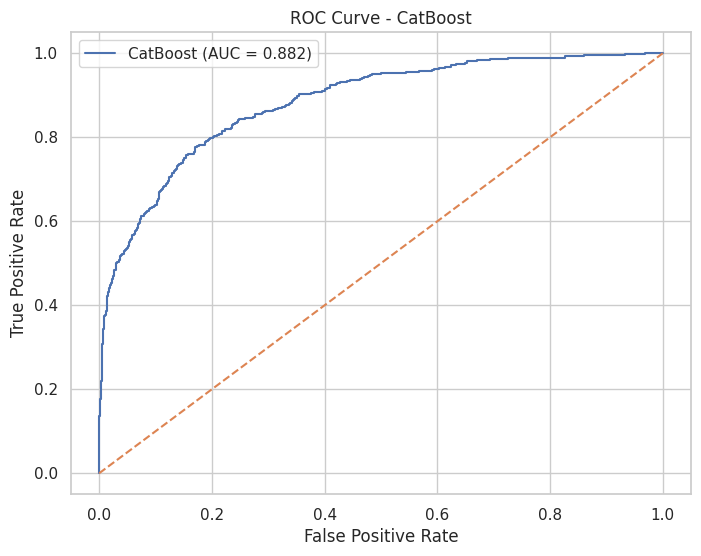

In [128]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob_cat_best
)

auc = roc_auc_score(
    y_test,
    y_prob_cat_best
)

plt.figure(figsize=(8,6))

plt.plot(

    fpr,
    tpr,

    label=f"CatBoost (AUC = {auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - CatBoost")

plt.legend()

plt.show()

THRESHOLD TUNING FINAL

In [129]:
from sklearn.metrics import (

    precision_score,
    recall_score,
    f1_score
)

thresholds = [

    0.2,
    0.25,
    0.3,
    0.35,
    0.4,
    0.45,
    0.5
]

for t in thresholds:

    y_pred_t = (
        y_prob_cat_best >= t
    ).astype(int)

    print(f"\n===== Threshold {t} =====")

    print(
        "Precision:",
        precision_score(
            y_test,
            y_pred_t
        )
    )

    print(
        "Recall:",
        recall_score(
            y_test,
            y_pred_t
        )
    )

    print(
        "F1:",
        f1_score(
            y_test,
            y_pred_t
        )
    )


===== Threshold 0.2 =====
Precision: 0.5118483412322274
Recall: 0.7941176470588235
F1: 0.622478386167147

===== Threshold 0.25 =====
Precision: 0.5719769673704415
Recall: 0.7303921568627451
F1: 0.6415500538213132

===== Threshold 0.3 =====
Precision: 0.6074561403508771
Recall: 0.678921568627451
F1: 0.6412037037037037

===== Threshold 0.35 =====
Precision: 0.6521739130434783
Recall: 0.625
F1: 0.6382978723404256

===== Threshold 0.4 =====
Precision: 0.688953488372093
Recall: 0.5808823529411765
F1: 0.6303191489361702

===== Threshold 0.45 =====
Precision: 0.7414965986394558
Recall: 0.5343137254901961
F1: 0.6210826210826211

===== Threshold 0.5 =====
Precision: 0.7827715355805244
Recall: 0.5122549019607843
F1: 0.6192592592592593


PRECISION-RECALL CURVE

In [130]:
from sklearn.metrics import (
    precision_recall_curve,
    auc
)

In [131]:
precision, recall, thresholds = precision_recall_curve(

    y_test,

    y_prob_cat_best
)

pr_auc = auc(recall, precision)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.7346


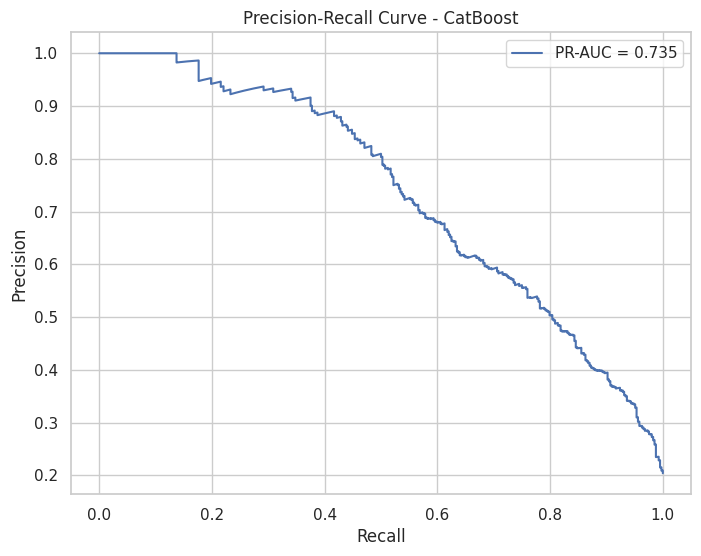

In [132]:
plt.figure(figsize=(8,6))

plt.plot(

    recall,
    precision,

    label=f"PR-AUC = {pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - CatBoost"
)

plt.legend()

plt.show()

ANÁLISE DOS ERROS

In [133]:
df_erros = X_test.copy()

df_erros["Real"] = y_test.values

df_erros["Predito"] = y_pred_cat_best

df_erros["Prob_Churn"] = y_prob_cat_best

In [134]:
falsos_negativos = df_erros[

    (df_erros["Real"] == 1) &
    (df_erros["Predito"] == 0)
]

falsos_negativos.head()

,PontuacaoCredito,Localizacao,Genero,Idade,TempoRelacionamento,Saldo,NumeroProdutos,PossuiCartaoCredito,MembroAtivo,SalarioEstimado,...,MultiProduto,PerfilIdealProdutos,FaixaSalario,FaixaPontos,ClienteRiscoMaximo,MultiProdutoAlemanha,MultiProdutoIdadeAlta,Real,Predito,Prob_Churn
6539,697,France,Female,45,1,0.00,2,1,0,46807.62,...,0,1,"(41050.736, 80238.34]","(529.0, 605.0]",0,0,0,1,0,0.175178
2560,650,Spain,Female,30,6,0.00,1,0,0,67997.13,...,0,0,"(41050.736, 80238.34]","(921.0, 1000.0]",0,0,0,1,0,0.188054
316,559,France,Male,49,2,147069.78,1,1,0,120540.83,...,0,0,"(119710.038, 159836.726]","(118.999, 295.0]",0,0,0,1,0,0.457136
3317,779,France,Male,71,3,0.00,2,1,1,146895.36,...,0,1,"(119710.038, 159836.726]","(840.0, 921.0]",0,0,0,1,0,0.016982
3969,551,Spain,Male,27,2,113873.22,1,1,1,85129.77,...,0,0,"(80238.34, 119710.038]","(452.0, 529.0]",0,0,0,1,0,0.041591


FEATURE IMPORTANCE EM %

In [135]:
importancia_pct = (
    importancias / importancias.sum()
) * 100

In [136]:
top15 = importancia_pct.head(15)

top15

Idade                    17.200410
Perfil Ideal Produtos    15.716212
NumeroProdutos           10.501415
Localização Alemanha      8.594954
Membro Ativo              7.867760
Saldo                     7.687576
Idade Alto Churn          7.016407
Múltiplos Produtos        6.121798
FaixaSaldo_Zero           2.570121
FaixaSaldo_Alto           2.229067
Salário Estimado          1.933598
Pontuação Crédito         1.793115
FaixaEtaria_Senior        1.452119
Genero_Female             1.240341
Gênero Masculino          1.212457
dtype: float64

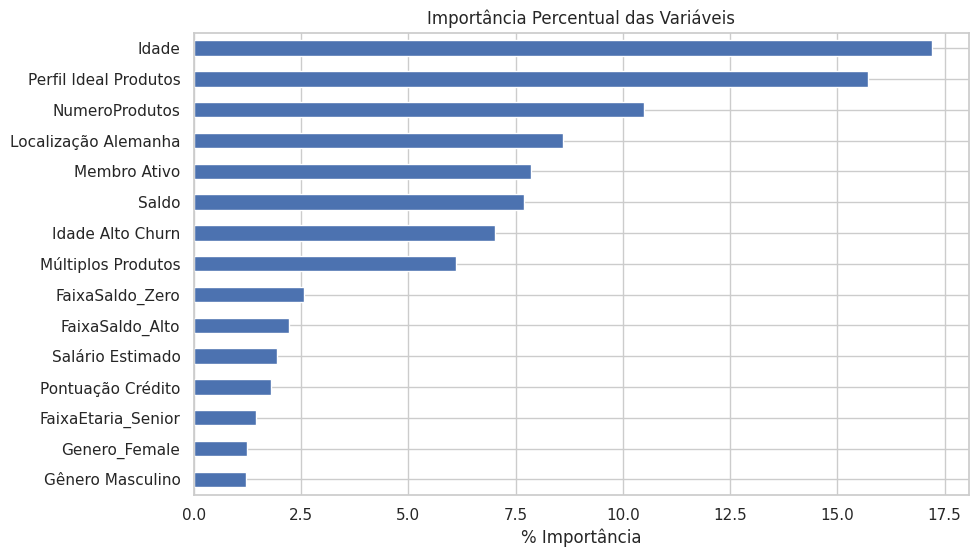

In [137]:
plt.figure(figsize=(10,6))

top15.sort_values().plot(
    kind="barh"
)

plt.xlabel("% Importância")

plt.title(
    "Importância Percentual das Variáveis"
)

plt.show()

SHAP

Responder: Por que o modelo prevê churn?

In [138]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [139]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [140]:
# preprocessador treinado
preprocessor_fit = best_cat.named_steps["preprocessor"]

# modelo treinado
cat_model = best_cat.named_steps["model"]

In [141]:
X_train_transformed = preprocessor_fit.transform(X_train)

X_test_transformed = preprocessor_fit.transform(X_test)

In [142]:
feature_names = preprocessor_fit.get_feature_names_out()

In [143]:
X_test_transformed = pd.DataFrame(

    X_test_transformed,

    columns=feature_names
)

In [144]:
explainer = shap.TreeExplainer(cat_model)

In [145]:
shap_values = explainer.shap_values(
    X_test_transformed
)

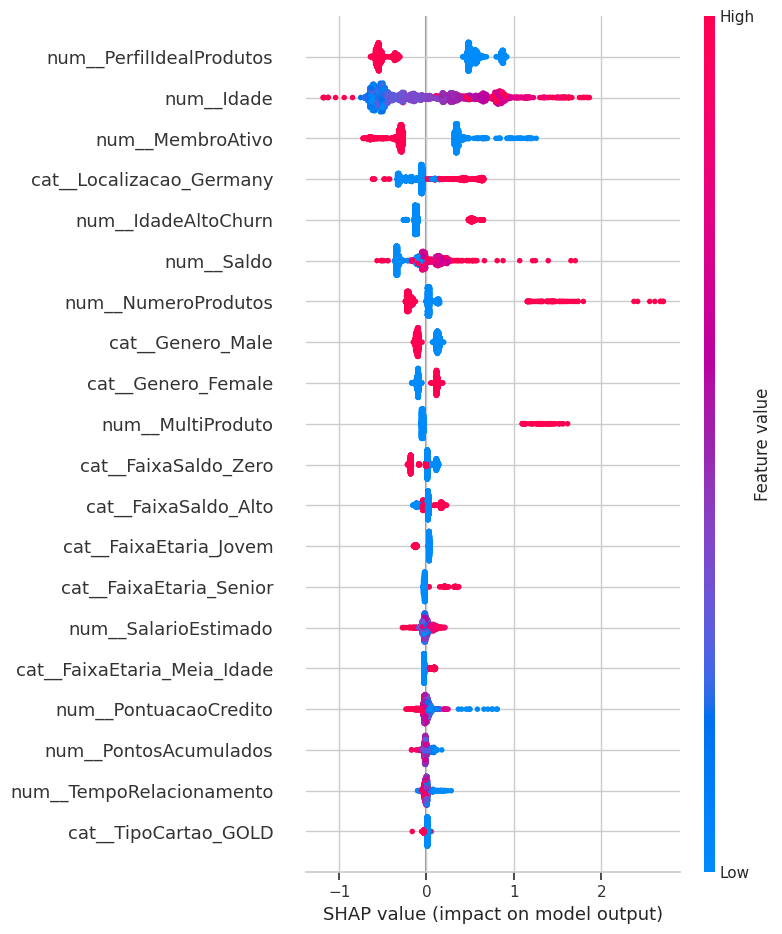

In [146]:
shap.summary_plot(

    shap_values,

    X_test_transformed,

    feature_names=feature_names
)

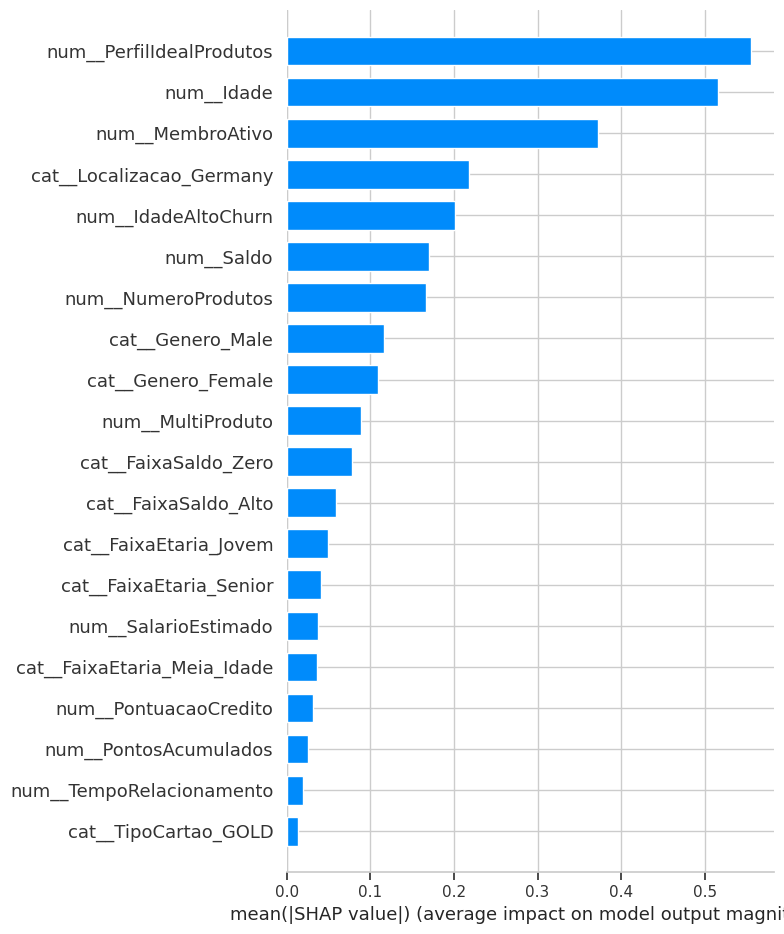

In [147]:
shap.summary_plot(

    shap_values,

    X_test_transformed,

    plot_type="bar"
)

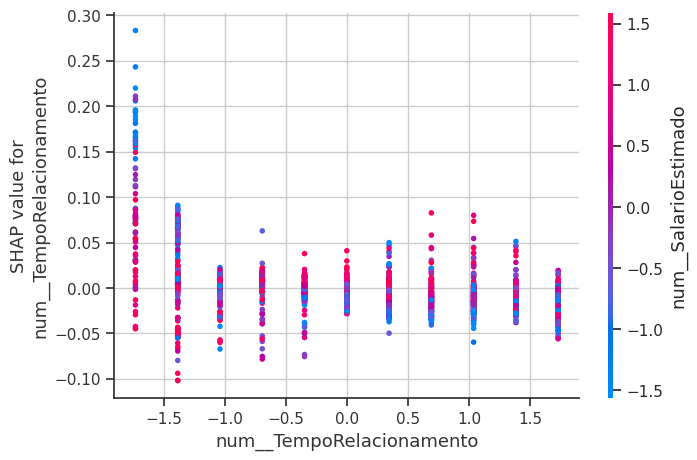

In [148]:
shap.dependence_plot(

    "num__TempoRelacionamento",

    shap_values,

    X_test_transformed
)

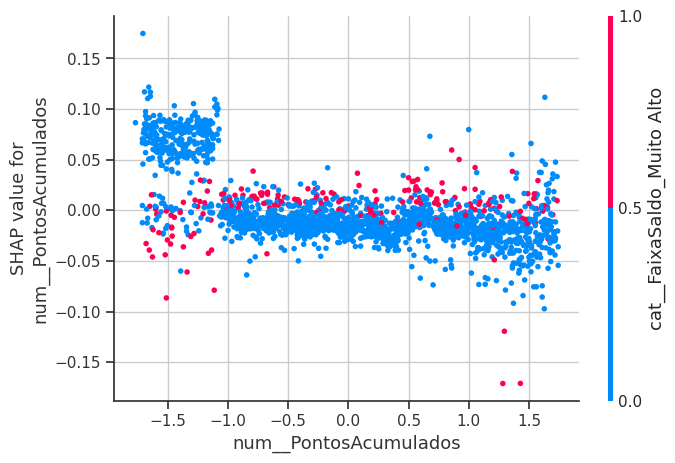

In [149]:
shap.dependence_plot(

    "num__PontosAcumulados",

    shap_values,

    X_test_transformed
)

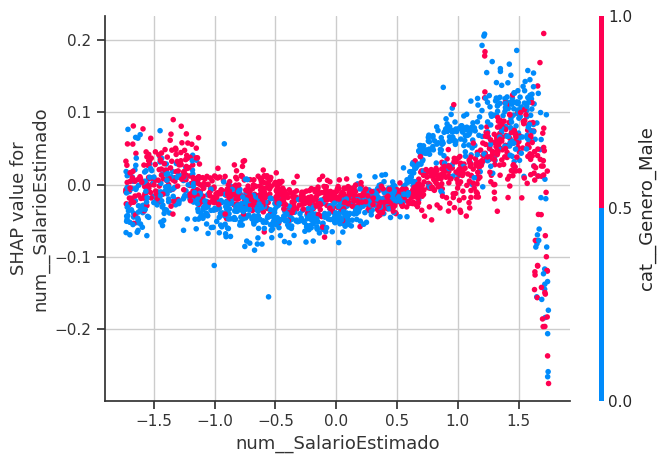

In [150]:
shap.dependence_plot(

    "num__SalarioEstimado",

    shap_values,

    X_test_transformed
)

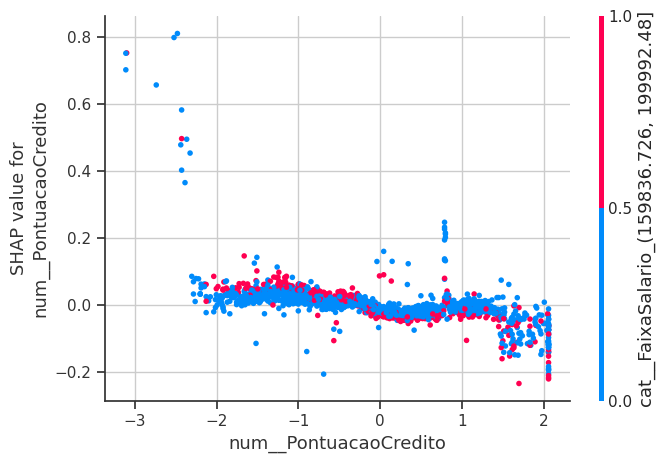

In [151]:
shap.dependence_plot(

    "num__PontuacaoCredito",

    shap_values,

    X_test_transformed
)

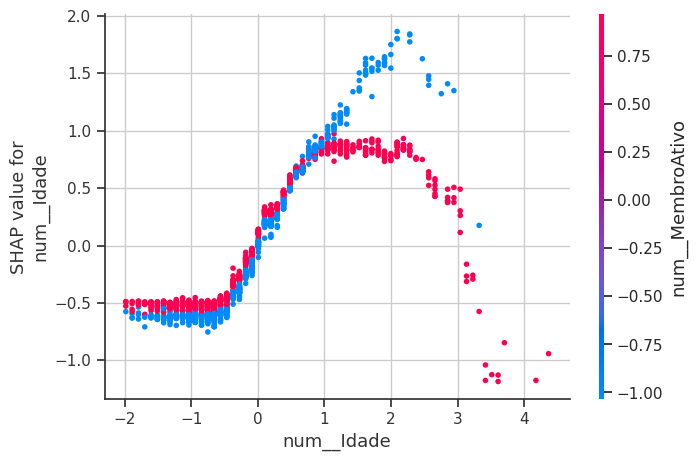

In [152]:
shap.dependence_plot(

    "num__Idade",

    shap_values,

    X_test_transformed
)

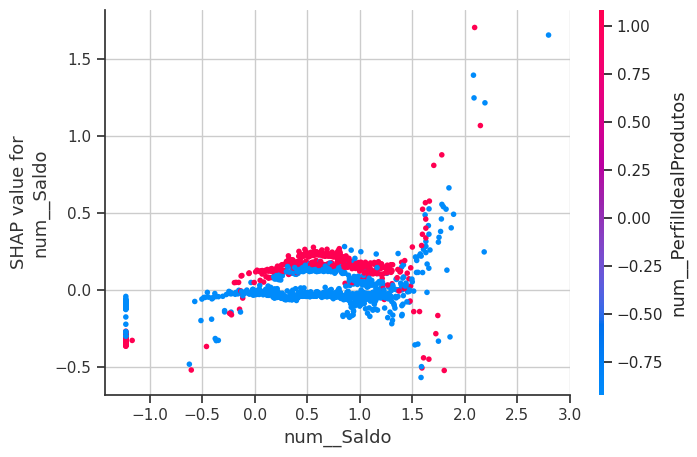

In [153]:
shap.dependence_plot(

    "num__Saldo",

    shap_values,

    X_test_transformed
)

Explicaçao Local

In [154]:
cliente = 10

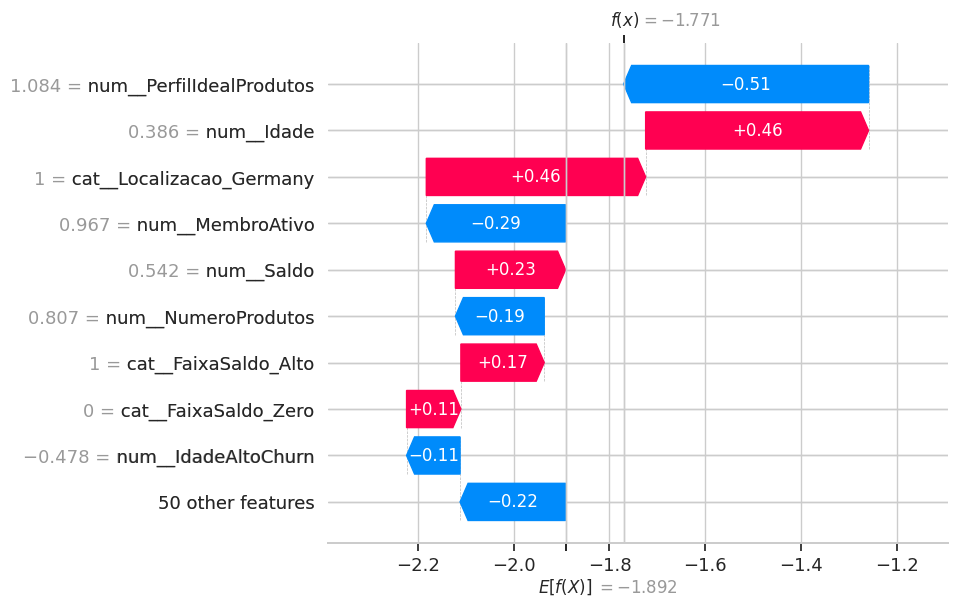

In [155]:
shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[cliente],

        base_values=explainer.expected_value,

        data=X_test_transformed.iloc[cliente],

        feature_names=feature_names
    )
)

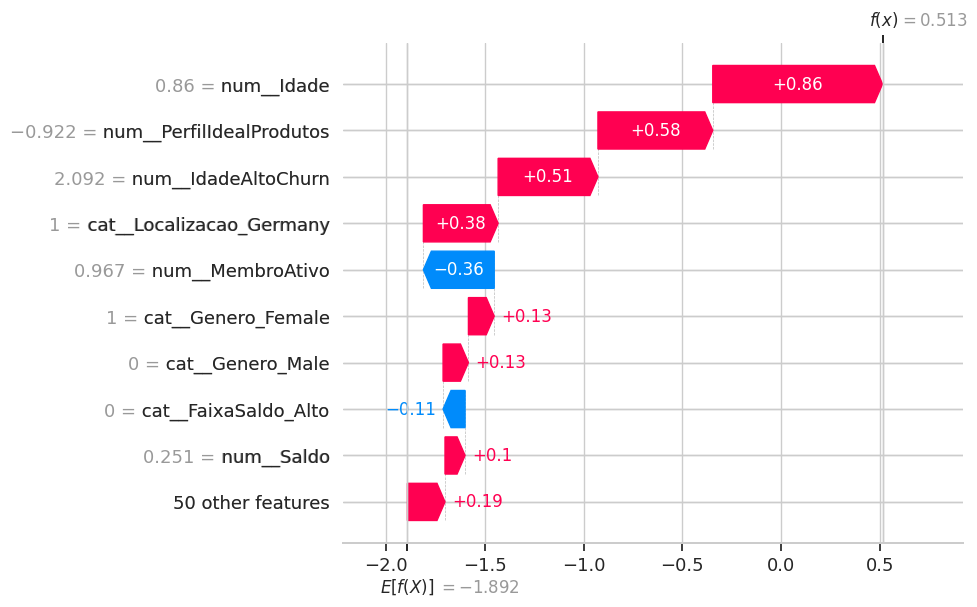

In [156]:
cliente = 980

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[cliente],

        base_values=explainer.expected_value,

        data=X_test_transformed.iloc[cliente],

        feature_names=feature_names
    )
)

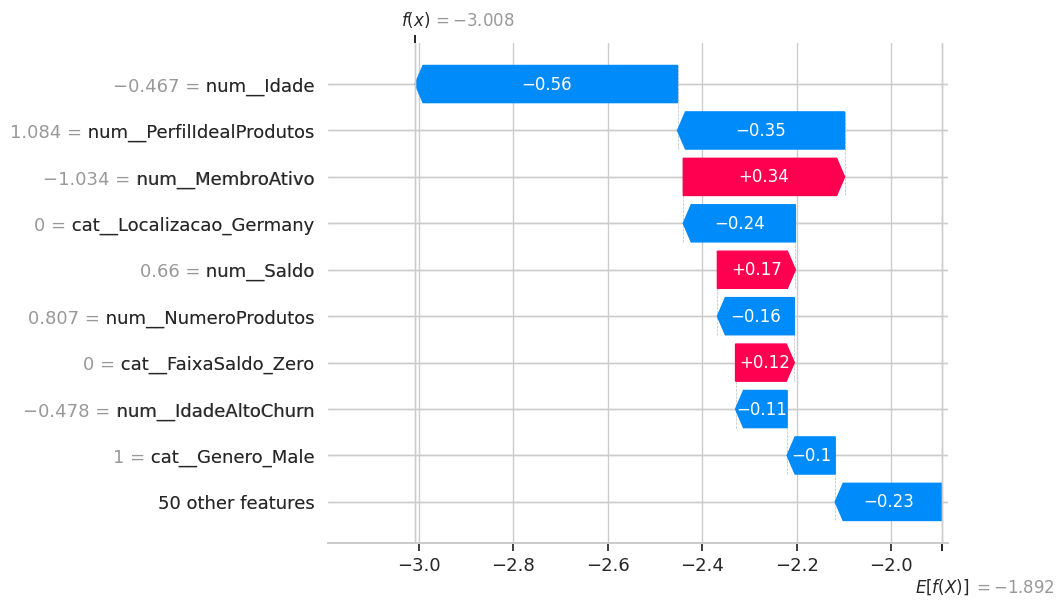

In [157]:
cliente = 377

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[cliente],

        base_values=explainer.expected_value,

        data=X_test_transformed.iloc[cliente],

        feature_names=feature_names
    )
)

Gráficos

In [158]:
feature_names = [

    nome.replace("num__", "")
        .replace("cat__", "")
        .replace("_1", "")
        .replace("Localizacao_Germany", "Localização Alemanha")
        .replace("Localizacao_Spain", "Localização Espanha")
        .replace("Genero_Male", "Gênero Masculino")
        .replace("MembroAtivo", "Membro Ativo")
        .replace("PossuiCartaoCredito", "Possui Cartão")
        .replace("PerfilIdealProdutos", "Perfil Ideal Produtos")
        .replace("PontuacaoCredito", "Pontuação Crédito")
        .replace("PontosAcumulados", "Pontos Acumulados")
        .replace("SalarioEstimado", "Salário Estimado")
        .replace("TempoRelacionamento", "Tempo Relacionamento")
        .replace("MultiProduto", "Múltiplos Produtos")
        .replace("Saldo", "Saldo")
        .replace("Idade", "Idade")

    for nome in feature_names
]

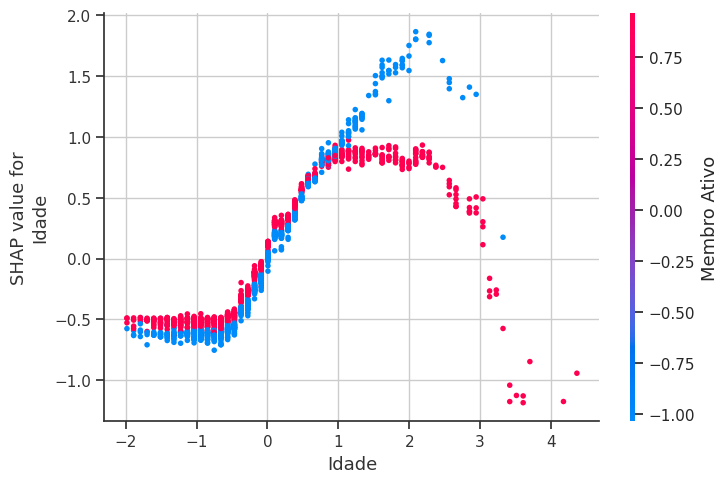

In [159]:
import shap
import matplotlib.pyplot as plt

shap.dependence_plot(

    "Idade",

    shap_values,

    X_test_transformed,

    feature_names=feature_names,

    show=False
)

plt.tight_layout()

plt.show()

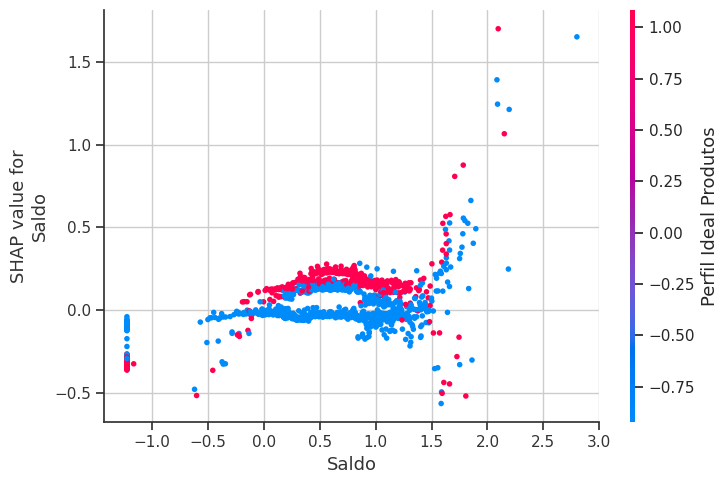

In [160]:
import shap
import matplotlib.pyplot as plt

shap.dependence_plot(

    "Saldo",

    shap_values,

    X_test_transformed,

    feature_names=feature_names,

    show=False
)

plt.tight_layout()

plt.show()

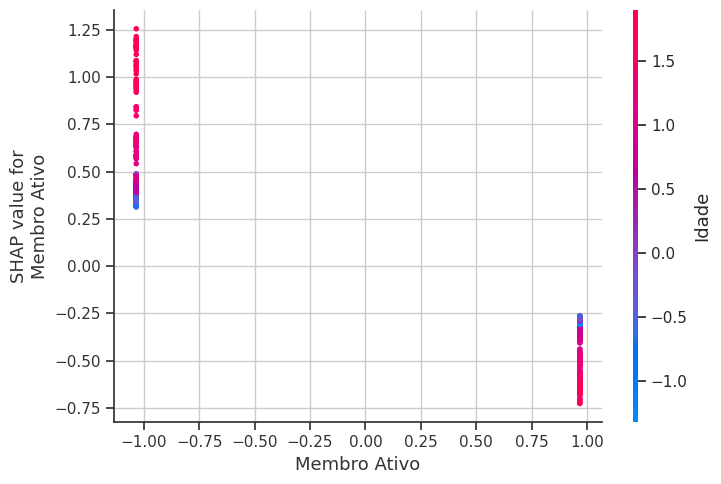

In [161]:
import shap
import matplotlib.pyplot as plt

shap.dependence_plot(

    "Membro Ativo",

    shap_values,

    X_test_transformed,

    feature_names=feature_names,

    show=False
)

plt.tight_layout()

plt.show()

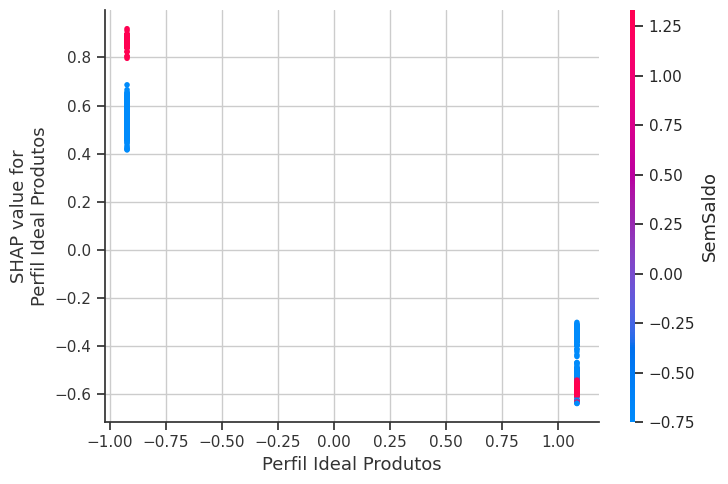

In [162]:
import shap
import matplotlib.pyplot as plt

shap.dependence_plot(

    "Perfil Ideal Produtos",

    shap_values,

    X_test_transformed,

    feature_names=feature_names,

    show=False
)

plt.tight_layout()

plt.show()

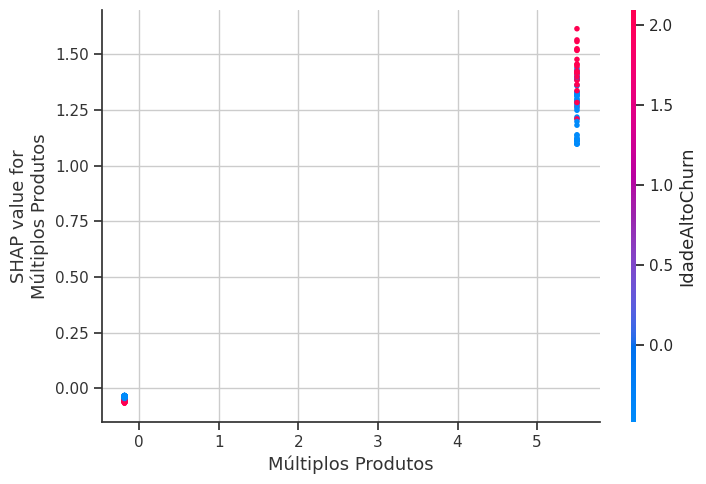

In [163]:
import shap
import matplotlib.pyplot as plt

shap.dependence_plot(

    "Múltiplos Produtos",

    shap_values,

    X_test_transformed,

    feature_names=feature_names,

    show=False
)

plt.tight_layout()

plt.show()

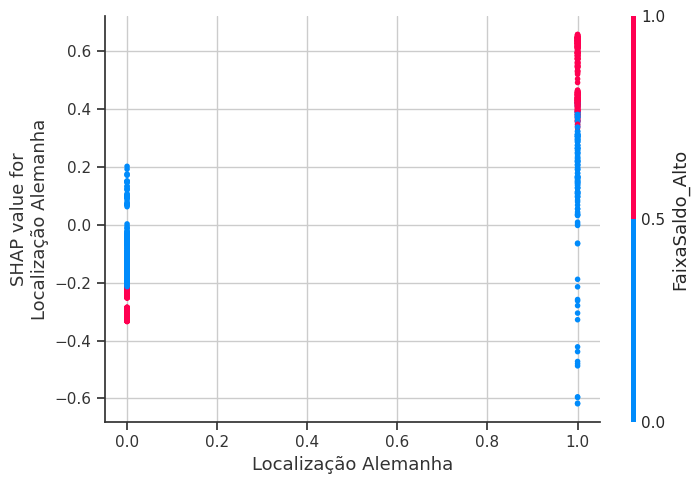

In [164]:
import shap
import matplotlib.pyplot as plt

shap.dependence_plot(

    "Localização Alemanha",

    shap_values,

    X_test_transformed,

    feature_names=feature_names,

    show=False
)

plt.tight_layout()


plt.show()

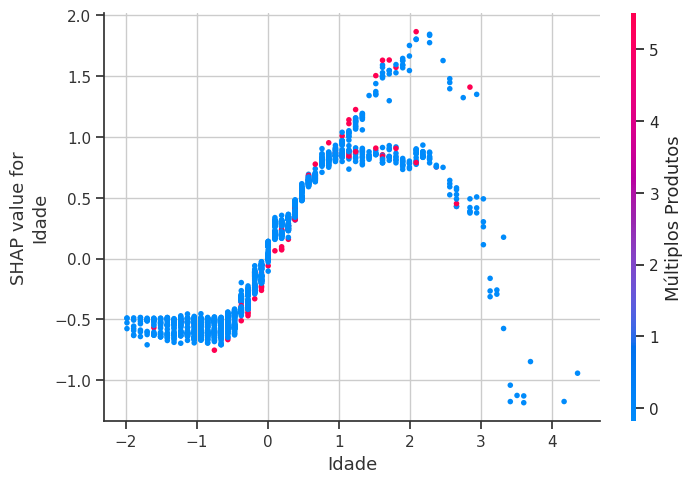

In [165]:
import shap
import matplotlib.pyplot as plt

shap.dependence_plot(

    "Idade",

    shap_values,

    X_test_transformed,

    interaction_index="Múltiplos Produtos",

    feature_names=feature_names,

    show=False
)

plt.tight_layout()

plt.show()

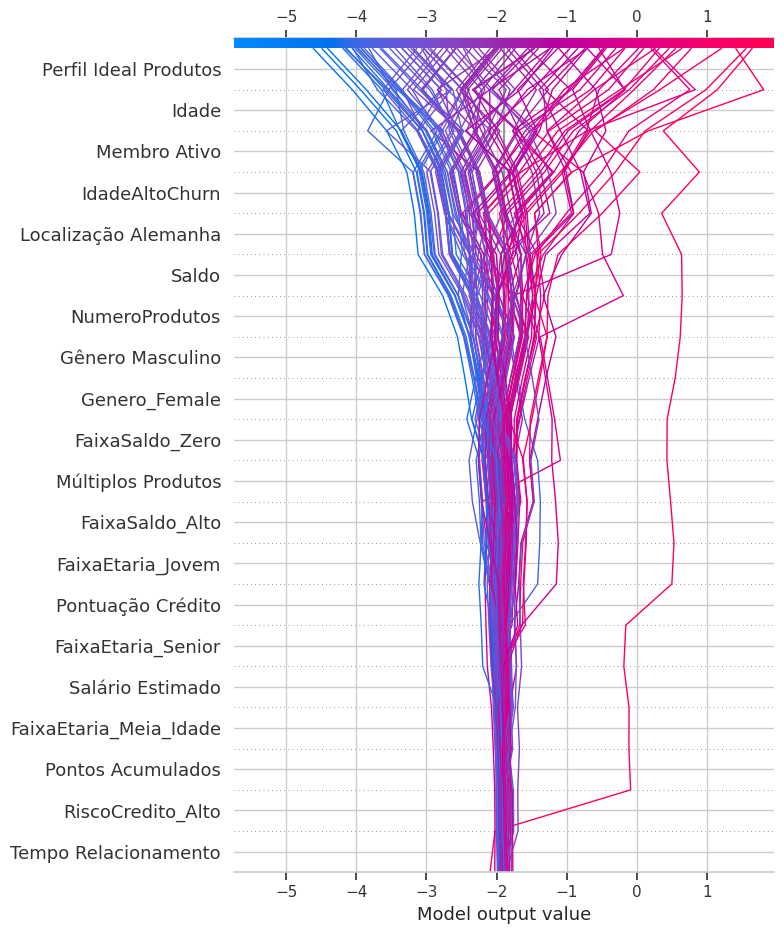

In [166]:
import shap
import matplotlib.pyplot as plt

shap.decision_plot(

    explainer.expected_value,

    shap_values[:100],

    feature_names=feature_names,

    show=False
)

plt.tight_layout()

plt.show()

Figuras modelo final

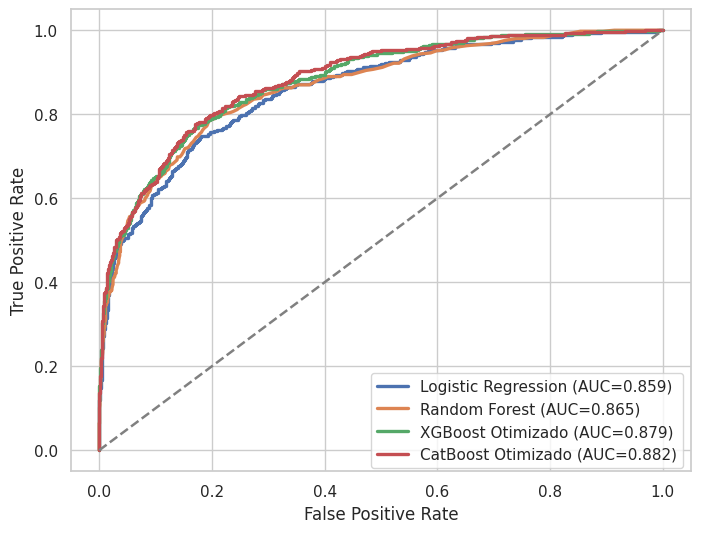

In [167]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8,6))

modelos = [

    ("Logistic Regression", y_prob_log),

    ("Random Forest", y_prob_rf),

    ("XGBoost Otimizado", y_prob_xgb_best),

    ("CatBoost Otimizado", y_prob_cat_best)
]

for nome, y_prob in modelos:

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(

        fpr,

        tpr,

        linewidth=2.4,

        label=f"{nome} (AUC={auc:.3f})"
    )

# Linha aleatória
plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    linewidth=1.8,

    color="gray"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

# Legenda mais abaixo
plt.legend(

    fontsize=11,

    loc="lower right",

    bbox_to_anchor=(1.0, -0.01),

    frameon=True
)

plt.show()

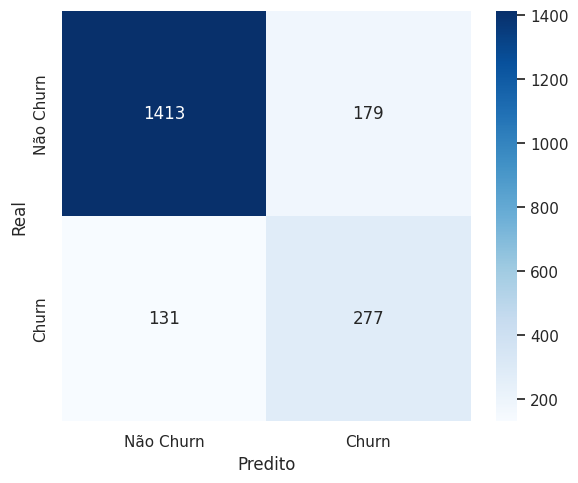

In [168]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_new
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Não Churn",
        "Churn"
    ],

    yticklabels=[
        "Não Churn",
        "Churn"
    ]
)

plt.xlabel("Predito")
plt.ylabel("Real")


plt.tight_layout()

plt.show()